# CELDA 001

## Proyecto

Clasificación multiclase de objetos (RGB) con pipeline de representación + fine-tuning.

### Clases

teclado, mouse, pantalla, cpu, silla, mesa

### Objetivo general

Entrenar y evaluar un sistema de clasificación de imágenes (6 clases) mediante un enfoque de dos etapas:

1. Aprendizaje de representación con un Autoencoder (AE) cuyo encoder se inicializa con pesos preentrenados en ImageNet (EfficientNet-B0) y se ajusta a nuestro dominio vía reconstrucción (pérdida L1/MAE).

2. Clasificación: se acopla una cabeza clasificadora al encoder adaptado y se realiza fine-tuning controlado (freeze-then-finetune) con Cross-Entropy.

### Alcance

Clasificación de imagen completa (una etiqueta por imagen), medición de Accuracy, Precision/Recall/F1 macro, matriz de confusión, e interpretabilidad con Grad-CAM (6 imágenes).

### Insumos y supuestos

1. Datos: imágenes RGB en carpetas por clase (nombres de carpeta = etiqueta). Resolución original mayor a 224×224.

2. Preprocesado estándar (sin aumentación): Resize(short=256, antialias) → CenterCrop(224) → Normalizar (ImageNet).

    1. Justificación: las imágenes ya presentan diversidad real (ángulos/dispositivos/personas); normalizar con estadísticas ImageNet alinea la distribución de entrada con el encoder inicializado, estabilizando la optimización.

3. Split: se generará train/val/test estratificado (80/10/10) con semilla fija para reproducibilidad.

### Metodología

1. Representación previa + fine-tuning: Empezar desde un encoder preentrenado en ImageNet acelera la convergencia y mejora la eficiencia de datos en conjuntos pequeños/medianos. Ajustarlo con un AE (reconstrucción con L1) adapta los rasgos a nuestro dominio antes de clasificar.

2. Freeze-then-finetune: Entrenar primero solo la cabeza evita inestabilidad inicial; luego abrir el encoder mejora la especialización a las 6 clases sin sobreajuste temprano.

3. Métricas macro: Precision/Recall/F1 macro ponderan por igual todas las clases (útil incluso con balance), y la matriz de confusión revela confusiones específicas (p. ej., teclado vs mouse).
4. Grad-CAM: valida que el modelo “mira” el objeto relevante y no artefactos de fondo.

### Entregables

1. Pesos del encoder tras AE: encoder_ae.pth

2. Mejor checkpoint del clasificador (encoder + cabeza): model_best.pth

4. Predicciones de test por archivo: predicciones_test.csv (filepath, pred_label, pred_score)

5. Se guardarán automáticamente en Drive dentro de outputs/.

### Criterios de éxito deseables

1. Entrenamiento completo ≤ ~15 min en Colab con GPU (uso de AMP y batch adaptativo 32→16).

2. Métricas consistentes entre validación y test (sin señales fuertes de sobreajuste).

3. Grad-CAM coherente (activaciones sobre el objeto).

### Estructura del cuaderno (siguientes celdas)

1. Configuración y reproducibilidad

2. Montaje de Drive y rutas

3. Exploración del dataset

4. Split estratificado

5. Transforms (resize/normalizar) y DataLoaders

6. AE (EfficientNet-B0 encoder + decoder) + entrenamiento (L1)

7. Cabeza de clasificación + Fase 1 (freeze)

8. Fine-tuning + selección de model_best.pth

9. Evaluación (test) + matriz de confusión

10. Grad-CAM (6 imágenes)

11. Inferencia por lote (test) + CSV

12. Verificación de artefactos y notas finales

### Notas finales

1. Se usaron presos preentrenados para el entrenamiento del AE (Autoencoder).

2. Este notebook se generó el 21 de octubre de 2025, alrededor de las 23:00 horas. Por lo tanto, las imágenes utilizadas correpsonden a las que fueron cargadas hasta ese momento en el repositorio https://github.com/Gerardo-cursos/objetos_salon.

3. Los archivos .pth son demsiado pesados para que GitHub los soporte, por ello, se disponen los siquientes enlaces para su consulta:

    - Pesos para el AE y para el modelo en: https://drive.google.com/drive/folders/1iKJjGM4CEUy0GdWUuLipsIv0v6zdMCGR?usp=sharing

    - csv con las predicciones sobre le conjunto de prueba: https://drive.google.com/drive/folders/1fVAlR-nGiW3AG-w_JjzX161rFOoxM7tM?usp=sharing
    

In [ ]:
# CELDA 002
'''
Relacionar google drive con Collab, para poder usar mi drive como almacenamiento de archivos,
y como lugar donde van a reposar los outputs que se generen en este script.
'''

from google.colab import drive
drive.mount('/content/drive')
# Ejecutar el código anterior y aceptar lo solicitado; permisos y accesos

Mounted at /content/drive


In [ ]:
# CELDA 003
'''
Definir las rutas para guardar las figuras, tablas y notebooks.
Dfinir las rutas para almacenar los resultados.
'''

import os

# Definir las rutas base
base = '/content/drive/MyDrive/taller8' # Debe crearse una carpeta previamente y directamente en Drive con el nombre de taller8
figs = os.path.join(base, 'figuras')
codes = os.path.join(base, 'codigos')
data = os.path.join(base, 'datos')
outputs = os.path.join(base, 'outputs')
pesos_dir = os.path.join(outputs, "pesos") # para encoder_ae.pth y model_best.pth
csv_dir = os.path.join(outputs, "tablas") # para predicciones_test.csv

# Crear las rutas sino existen
os.makedirs(figs, exist_ok=True)
os.makedirs(codes, exist_ok=True)
os.makedirs(data, exist_ok=True)
os.makedirs(outputs, exist_ok=True)
os.makedirs(pesos_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)

In [ ]:
# CELDA 004

import os
import glob
from PIL import Image
import pandas as pd
import numpy as np
import hashlib

print("🚀 Iniciando exploración rápida del dataset...")

# 1. Descubrir clases
print("\n🔍 Descubriendo clases...")
discovered_classes = [d for d in os.listdir(data) if os.path.isdir(os.path.join(data, d))]
expected_classes = {'teclado', 'mouse', 'pantalla', 'cpu', 'silla', 'mesa'}

print(f"Clases encontradas: {discovered_classes}")
print(f"Clases esperadas: {list(expected_classes)}")

missing_classes = expected_classes - set(discovered_classes)
extra_classes = set(discovered_classes) - expected_classes

if missing_classes:
    print(f"⚠️ ¡Atención! Faltan las siguientes clases esperadas: {list(missing_classes)}")
if extra_classes:
    print(f"⚠️ ¡Atención! Se encontraron clases extra no esperadas: {list(extra_classes)}")
if not missing_classes and not extra_classes:
    print("✅ Todas las clases esperadas fueron encontradas y no hay clases extra.")

# 2. Enumerar archivos válidos y Chequeo de salud de imágenes
print("\n📸 Enumerando archivos válidos y chequeando salud de imágenes...")

image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.webp', '*.bmp', '*.tif', '*.tiff']
all_image_paths = []
image_data = [] # To store health and size info

for class_name in discovered_classes:
    class_path = os.path.join(data, class_name)
    class_image_paths = []
    for ext in image_extensions:
        class_image_paths.extend(glob.glob(os.path.join(class_path, '**', ext), recursive=True))
        class_image_paths.extend(glob.glob(os.path.join(class_path, '**', ext.upper()), recursive=True)) # Case-insensitive

    all_image_paths.extend(class_image_paths)

    for img_path in class_image_paths:
        is_corrupt = False
        is_rgb = True
        width, height = None, None
        try:
            with Image.open(img_path) as img:
                img.verify() # Verify file integrity
                img = Image.open(img_path) # Re-open after verify
                if img.mode != 'RGB':
                    is_rgb = False
                width, height = img.size
        except Exception as e:
            is_corrupt = True
            # print(f"⚠️ Error abriendo o verificando {img_path}: {e}") # Optional: print errors

        image_data.append({
            'filepath': img_path,
            'class': class_name,
            'is_corrupt': is_corrupt,
            'is_rgb': is_rgb,
            'width': width,
            'height': height
        })

image_df = pd.DataFrame(image_data)
valid_images_df = image_df[(~image_df['is_corrupt']) & (image_df['is_rgb'])]
corrupt_images_df = image_df[image_df['is_corrupt']]
non_rgb_images_df = image_df[(~image_df['is_corrupt']) & (~image_df['is_rgb'])]

print(f"Total archivos con extensiones válidas encontrados: {len(image_df)}")
print(f"Imágenes sanas (no corruptas y RGB): {len(valid_images_df)}")
if len(corrupt_images_df) > 0:
    print(f"⚠️ Imágenes corruptas encontradas: {len(corrupt_images_df)}")
if len(non_rgb_images_df) > 0:
    print(f"⚠️ Imágenes no-RGB encontradas (ignoradas para stats): {len(non_rgb_images_df)}")


# 3. Estadísticas por clase
print("\n📊 Generando estadísticas por clase...")

stats_list = []
for class_name in discovered_classes:
    class_df = image_df[image_df['class'] == class_name]
    valid_class_df = valid_images_df[valid_images_df['class'] == class_name]

    total_files = len(class_df)
    corrupt_count = class_df['is_corrupt'].sum()
    non_rgb_count = class_df[~class_df['is_corrupt']]['is_rgb'].sum() # Count non-RGB among non-corrupt

    if len(valid_class_df) > 0:
        heights = valid_class_df['height'].dropna()
        widths = valid_class_df['width'].dropna()
        min_h, min_w = heights.min(), widths.min()
        median_h, median_w = heights.median(), widths.median()
        max_h, max_w = heights.max(), widths.max()
        min_size = f"{int(min_h)}x{int(min_w)}"
        median_size = f"{int(median_h)}x{int(median_w)}"
        max_size = f"{int(max_h)}x{int(max_w)}"
    else:
        min_size, median_size, max_size = "N/A", "N/A", "N/A"

    stats_list.append({
        'Clase': class_name,
        'Archivos Totales': total_files,
        'Corruptas': int(corrupt_count),
        'No-RGB': int(non_rgb_count),
        'Sanas (RGB)': len(valid_class_df),
        'Min Size (HxW)': min_size,
        'Median Size (HxW)': median_size,
        'Max Size (HxW)': max_size
    })

stats_df = pd.DataFrame(stats_list).sort_values(by='Clase')
print("Resumen estadístico por clase:")
display(stats_df)

# 4. Detección de duplicados exactos (aproximada con thumbnail hash)
print("\n🕵️‍♂️ Detectando posibles duplicados (hash de thumbnail)...")

def get_thumbnail_hash(filepath, size=(128, 128)):
    try:
        with Image.open(filepath) as img:
            img = img.convert('RGB') # Ensure RGB
            img = img.resize(size, Image.Resampling.LANCZOS) # Resize with antialias/Lanczos
            img_bytes = img.tobytes()
            return hashlib.md5(img_bytes).hexdigest()
    except Exception:
        return None # Return None for corrupt or unprocessable images

# Only process valid images for hashing
valid_images_df['thumbnail_hash'] = valid_images_df['filepath'].apply(get_thumbnail_hash)

duplicate_hashes = valid_images_df[valid_images_df['thumbnail_hash'].duplicated(keep=False)]['thumbnail_hash'].unique()

if len(duplicate_hashes) > 0:
    print(f"⚠️ Se encontraron {len(duplicate_hashes)} hashes de thumbnail con posibles duplicados.")
    print("Resumen de posibles duplicados (hasta 3 rutas por hash/clase):")

    duplicate_summary = {}
    for hash_val in duplicate_hashes:
        hash_matches = valid_images_df[valid_images_df['thumbnail_hash'] == hash_val]
        for class_name in hash_matches['class'].unique():
            if class_name not in duplicate_summary:
                duplicate_summary[class_name] = {}
            if hash_val not in duplicate_summary[class_name]:
                duplicate_summary[class_name][hash_val] = []

            # Collect up to 3 filepaths for this hash and class
            filepaths_in_class = hash_matches[hash_matches['class'] == class_name]['filepath'].tolist()
            duplicate_summary[class_name][hash_val].extend(filepaths_in_class[:3])

    # Print summary
    for class_name, hashes in duplicate_summary.items():
        print(f"\nClase: {class_name}")
        for hash_val, filepaths in hashes.items():
            print(f"  Hash: {hash_val[:8]}... ({len(filepaths)} ejemplos)")
            for fp in filepaths:
                 print(f"    - {fp}")
else:
    print("✅ No se encontraron posibles duplicados exactos (basado en hash de thumbnail).")


# 5. Muestras de inspección
print("\n👀 Mostrando rutas de ejemplo por clase (para inspección manual):")

for class_name in discovered_classes:
    class_paths = valid_images_df[valid_images_df['class'] == class_name]['filepath'].tolist()
    print(f"\nClase: {class_name}")
    if len(class_paths) > 0:
        # Show up to 2 examples
        for i, path in enumerate(class_paths[:2]):
            print(f"  - {path}")
    else:
        print("  No hay imágenes sanas en esta clase para mostrar ejemplos.")


print("\n🎉 Exploración del dataset completada.")

🚀 Iniciando exploración rápida del dataset...

🔍 Descubriendo clases...
Clases encontradas: ['cpu', 'mesa', 'mouse', 'pantalla', 'silla', 'teclado']
Clases esperadas: ['mesa', 'pantalla', 'mouse', 'silla', 'cpu', 'teclado']
✅ Todas las clases esperadas fueron encontradas y no hay clases extra.

📸 Enumerando archivos válidos y chequeando salud de imágenes...
Total archivos con extensiones válidas encontrados: 905
Imágenes sanas (no corruptas y RGB): 905

📊 Generando estadísticas por clase...
Resumen estadístico por clase:


,Clase,Archivos Totales,Corruptas,No-RGB,Sanas (RGB),Min Size (HxW),Median Size (HxW),Max Size (HxW)
0,cpu,129,0,129,129,224x224,1280x720,3840x2160
1,mesa,161,0,161,161,224x224,1080x720,1280x1920
2,mouse,149,0,149,149,224x224,1280x720,2160x3840
3,pantalla,151,0,151,151,224x224,720x848,2160x3840
4,silla,165,0,165,165,224x224,1280x720,1920x1080
5,teclado,150,0,150,150,224x224,720x1280,2160x3840



🕵️‍♂️ Detectando posibles duplicados (hash de thumbnail)...
⚠️ Se encontraron 28 hashes de thumbnail con posibles duplicados.
Resumen de posibles duplicados (hasta 3 rutas por hash/clase):

Clase: mesa
  Hash: f4f35d60... (1 ejemplos)
    - /content/drive/MyDrive/taller8/datos/mesa/20251695012_mesa_0001.png

Clase: mouse
  Hash: f4f35d60... (2 ejemplos)
    - /content/drive/MyDrive/taller8/datos/mouse/20172167090_Mouse_1.png
    - /content/drive/MyDrive/taller8/datos/mouse/20251695012_mouse_0001.png

Clase: pantalla
  Hash: f4f35d60... (1 ejemplos)
    - /content/drive/MyDrive/taller8/datos/pantalla/20251695012_pantalla_0001.png

Clase: silla
  Hash: 63338a20... (2 ejemplos)
    - /content/drive/MyDrive/taller8/datos/silla/20242695001_silla_009.png
    - /content/drive/MyDrive/taller8/datos/silla/20242691001_silla_009.png
  Hash: 984593df... (2 ejemplos)
    - /content/drive/MyDrive/taller8/datos/silla/20242691001_silla_003.png
    - /content/drive/MyDrive/taller8/datos/silla/20242695

In [ ]:
# CELDA 005
'''
Realiza el split estratificado (80/10/10) del dataset, ignorando imágenes
marcadas como corruptas o no-RGB en la exploración anterior (si se ejecutó).
Genera DataFrames y listas de rutas para cada split, y guarda manifiestos CSV.
'''

import os
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

print("🚀 Iniciando split estratificado del dataset...")

# Parámetros
RANDOM_SEED = 42
SPLIT = (0.8, 0.1, 0.1) # Debe sumar 1.0
SAVE_MANIFESTS = True
MANIFEST_PREFIX = "manifest"
EXPECTED_CLASSES = ["cpu","mesa","mouse","pantalla","silla","teclado"]
VALID_EXTS = {".jpg",".jpeg",".png",".webp",".bmp",".tif",".tiff"} # case-insensitive

# Validar parámetros de split
if sum(SPLIT) != 1.0:
    raise ValueError("El tuple SPLIT debe sumar 1.0")

# Rutas por clase (usar valid_images_df de CELDA 004 si existe, sino, construirla)
if 'valid_images_df' in globals():
    print("\n✅ Usando 'valid_images_df' de la exploración anterior.")
    all_image_paths = valid_images_df['filepath'].tolist()
    image_class_map = valid_images_df.set_index('filepath')['class'].to_dict()
else:
    print("\n⚠️ 'valid_images_df' no encontrada. Reconstruyendo lista de imágenes válidas...")
    all_image_paths = []
    image_class_map = {}
    for class_name in EXPECTED_CLASSES:
        class_path = os.path.join(data, class_name)
        if not os.path.isdir(class_path):
             print(f"⚠️ Directorio de clase '{class_name}' no encontrado en {data}. Ignorando.")
             continue

        class_image_paths = []
        for ext in VALID_EXTS:
            class_image_paths.extend(glob.glob(os.path.join(class_path, '**', f'*{ext}'), recursive=True))
            class_image_paths.extend(glob.glob(os.path.join(class_path, '**', f'*{ext.upper()}'), recursive=True))

        # Basic health check if not using valid_images_df
        valid_class_image_paths = []
        for img_path in class_image_paths:
            try:
                with Image.open(img_path) as img:
                    img.verify()
                    if img.mode == 'RGB':
                         valid_class_image_paths.append(img_path)
                         image_class_map[img_path] = class_name
                    else:
                         # print(f"Skipping non-RGB image: {img_path}") # Optional: verbose skip
                         pass
            except Exception:
                # print(f"Skipping corrupt image: {img_path}") # Optional: verbose skip
                pass

        all_image_paths.extend(valid_class_image_paths)


if not all_image_paths:
    raise FileNotFoundError(f"No se encontraron imágenes válidas en la ruta: {data}. Asegúrate de que los datos están montados y las rutas son correctas.")

# DataFrame base
print(f"\nTotal de imágenes sanas encontradas: {len(all_image_paths)}")
df = pd.DataFrame({'path': all_image_paths})
df['class'] = df['path'].map(image_class_map)

# Asegurar que solo tenemos clases esperadas y ordenar
df = df[df['class'].isin(EXPECTED_CLASSES)]
class_names = sorted(df['class'].unique().tolist()) # Order classes alphabetically
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}
print(f"\nMapeo de clases: {class_to_idx}")

if len(class_names) != len(EXPECTED_CLASSES):
     print(f"⚠️ Se encontraron {len(class_names)} clases únicas en los datos válidos, pero se esperaban {len(EXPECTED_CLASSES)}. Clases encontradas en datos válidos: {class_names}")


# Split estratificado 80/10/10
print("\n🔄 Realizando split estratificado (train/val/test)...")

# Paso 1: train vs temp (val + test)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=SPLIT[1] + SPLIT[2], random_state=RANDOM_SEED)
train_idx, temp_idx = next(sss1.split(df['path'], df['class']))

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

# Paso 2: temp -> val vs test
# Calculate the ratio of val to test from the original split
val_test_ratio = SPLIT[1] / (SPLIT[1] + SPLIT[2]) if (SPLIT[1] + SPLIT[2]) > 0 else 0.5 # Avoid division by zero

if (SPLIT[1] + SPLIT[2]) > 0 and len(temp_df) > 0:
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=1 - val_test_ratio, random_state=RANDOM_SEED)
    val_idx, test_idx = next(sss2.split(temp_df['path'], temp_df['class']))

    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)
else:
    # Handle cases where val+test split is 0 or no temp data
    val_df = pd.DataFrame(columns=df.columns)
    test_df = pd.DataFrame(columns=df.columns)
    if (SPLIT[1] + SPLIT[2]) > 0:
         print("⚠️ No hay datos suficientes para crear splits de validación/test. Son de tamaño 0.")


# Verificar disjunct sets
train_paths = set(train_df['path'])
val_paths = set(val_df['path'])
test_paths = set(test_df['path'])

if train_paths.intersection(val_paths):
    print("❌ Error: ¡Hay imágenes duplicadas entre train y val!")
if train_paths.intersection(test_paths):
    print("❌ Error: ¡Hay imágenes duplicadas entre train y test!")
if val_paths.intersection(test_paths):
    print("❌ Error: ¡Hay imágenes duplicadas entre val y test!")
if len(train_paths) + len(val_paths) + len(test_paths) != len(df):
     print("❌ Error: La suma de imágenes en los splits no coincide con el total de imágenes válidas.")
else:
    print("✅ Los conjuntos de train, val y test son disjuntos.")


# Resumen por split
print("\n📊 Resumen de conteos por clase en cada split:")

split_counts = pd.DataFrame({
    'train': train_df['class'].value_counts(),
    'val': val_df['class'].value_counts(),
    'test': test_df['class'].value_counts()
}).fillna(0).astype(int).sort_index()

split_counts['Total'] = split_counts.sum(axis=1)
split_counts.loc['Global Total'] = split_counts.sum() # Add global total row

display(split_counts)

# Verificar si alguna clase tiene 0 imágenes en algún split (excepto si el split es de tamaño 0)
for col in ['train', 'val', 'test']:
    if not split_counts[col].drop('Global Total').all() and split_counts.loc['Global Total', col] > 0:
        zero_classes = split_counts[split_counts[col] == 0].index.tolist()
        if 'Global Total' in zero_classes:
             zero_classes.remove('Global Total')
        if zero_classes:
            print(f"\n⚠️ ¡Atención! Las siguientes clases tienen 0 imágenes en el split '{col}': {zero_classes}")
            # Optional: Add logic here to suggest re-running with different seed or handle this case


# Manifiestos y variables de salida
train_paths = train_df['path'].tolist()
val_paths = val_df['path'].tolist()
test_paths = test_df['path'].tolist()

if SAVE_MANIFESTS:
    print(f"\n💾 Guardando manifiestos en {csv_dir}...")
    try:
        train_df.to_csv(os.path.join(csv_dir, f"{MANIFEST_PREFIX}_train.csv"), index=False)
        val_df.to_csv(os.path.join(csv_dir, f"{MANIFEST_PREFIX}_val.csv"), index=False)
        test_df.to_csv(os.path.join(csv_dir, f"{MANIFEST_PREFIX}_test.csv"), index=False)
        print("✅ Manifiestos guardados exitosamente.")
    except Exception as e:
        print(f"❌ Error al guardar manifiestos: {e}")


print("\n🎉 Split estratificado completado.")

🚀 Iniciando split estratificado del dataset...

✅ Usando 'valid_images_df' de la exploración anterior.

Total de imágenes sanas encontradas: 905

Mapeo de clases: {'cpu': 0, 'mesa': 1, 'mouse': 2, 'pantalla': 3, 'silla': 4, 'teclado': 5}

🔄 Realizando split estratificado (train/val/test)...
✅ Los conjuntos de train, val y test son disjuntos.

📊 Resumen de conteos por clase en cada split:


,train,val,test,Total
class,,,,
cpu,103,13,13,129
mesa,129,16,16,161
mouse,119,15,15,149
pantalla,121,15,15,151
silla,132,16,17,165
teclado,120,15,15,150
Global Total,724,90,91,905



💾 Guardando manifiestos en /content/drive/MyDrive/taller8/outputs/tablas...
✅ Manifiestos guardados exitosamente.

🎉 Split estratificado completado.


In [ ]:
# CELDA 006
'''
Definir Transforms para preprocesamiento de imágenes y una clase de Dataset
personalizada para cargar datos desde un DataFrame, aplicando los Transforms.
'''

import torch
from torchvision import transforms as T
from PIL import Image
import os

print("🚀 Definiendo Transforms y Dataset personalizado...")

# 1. Definir Transforms (sin aumentación)
# Resize preservando aspecto, CenterCrop y Normalizar con estadísticas ImageNet.
# Estos transforms serán idénticos para train, val y test.

train_transform = T.Compose([
    T.Resize(256, interpolation=T.InterpolationMode.LANCZOS), # Resize shorter side to 256
    T.CenterCrop(224), # Crop the center 224x224
    T.ToTensor(), # Convert PIL Image to PyTorch Tensor (scales to [0, 1])
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])

val_transform = train_transform # Transforms are the same for validation
test_transform = train_transform # Transforms are the same for testing

print("\n✅ Transforms definidos (Resize(256, LANCZOS) -> CenterCrop(224) -> ToTensor() -> Normalize(ImageNet)).")

# 2. Definir clase de Dataset personalizada (ImageDFDataset)
# Carga imágenes y etiquetas desde un DataFrame.

class ImageDFDataset(torch.utils.data.Dataset):
    def __init__(self, df, class_to_idx, transform=None):
        """
        Args:
            df (pd.DataFrame): DataFrame con columnas 'path' y 'class'.
            class_to_idx (dict): Diccionario que mapea nombres de clase a índices enteros.
            transform (callable, optional): Opcional transform a aplicar en una muestra.
        """
        self.df = df
        self.class_to_idx = class_to_idx
        self.transform = transform

        # Basic check for required columns
        if 'path' not in self.df.columns or 'class' not in self.df.columns:
            raise ValueError("DataFrame debe contener columnas 'path' y 'class'.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_path = self.df.iloc[idx]['path']
        class_name = self.df.iloc[idx]['class']

        try:
            # Abrir imagen con PIL y asegurar modo RGB
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            # Lanzar excepción clara si falla la lectura de la imagen
            raise RuntimeError(f"Error al cargar imagen {img_path}: {e}") from e

        # Aplicar transform si existe
        if self.transform:
            img_tensor = self.transform(img)
        else:
             # Convertir a tensor si no hay transform, manteniendo el rango [0, 1]
             img_tensor = T.ToTensor()(img)


        # Mapear nombre de clase a índice entero
        if class_name not in self.class_to_idx:
             raise ValueError(f"Clase desconocida '{class_name}' en {img_path}. Clase a idx mapeo: {self.class_to_idx}")

        label = self.class_to_idx[class_name]

        return img_tensor, label, img_path # Devolver tensor, etiqueta y ruta

print("✅ Clase ImageDFDataset definida.")


# 3. Crear instancias de Dataset para cada split
# train_df, val_df, test_df, class_to_idx ya deben existir en memoria de celdas anteriores.

if 'train_df' not in globals() or 'val_df' not in globals() or 'test_df' not in globals():
    raise RuntimeError("DataFrames de split (train_df, val_df, test_df) no encontrados. Ejecuta la CELDA 005 primero.")

if 'class_to_idx' not in globals():
     raise RuntimeError("class_to_idx mapeo no encontrado. Ejecuta la CELDA 005 primero.")


train_set = ImageDFDataset(df=train_df, class_to_idx=class_to_idx, transform=train_transform)
val_set = ImageDFDataset(df=val_df, class_to_idx=class_to_idx, transform=val_transform)
test_set = ImageDFDataset(df=test_df, class_to_idx=class_to_idx, transform=test_transform)

print("\n✅ Instancias de Dataset creadas para train, val y test.")

# 4. Impresión corta de resumen y verificación de __getitem__
print("\n📊 Resumen de Datasets y verificación de __getitem__:")
print(f"Tamaño del Training Set: {len(train_set)}")
print(f"Tamaño del Validation Set: {len(val_set)}")
print(f"Tamaño del Test Set: {len(test_set)}")

# Mostrar mapeo de clases ordenado
print("\nMapeo de clases (class_to_idx):")
sorted_classes = sorted(class_to_idx.items())
print(sorted_classes)


# Verificar __getitem__ para 1 muestra por split
print("\n🧪 Verificando __getitem__ para una muestra de cada split...")

try:
    img_tensor_train, label_train, path_train = train_set[0]
    print(f"  Train sample 0: Tensor shape={img_tensor_train.shape}, Label={label_train}, Path={path_train}")
except IndexError:
    print("  Skipping train sample check: Train set is empty.")
except Exception as e:
    print(f"  Error during train sample check: {e}")

try:
    img_tensor_val, label_val, path_val = val_set[0]
    print(f"  Val sample 0: Tensor shape={img_tensor_val.shape}, Label={label_val}, Path={path_val}")
except IndexError:
    print("  Skipping val sample check: Validation set is empty.")
except Exception as e:
    print(f"  Error during validation sample check: {e}")

try:
    img_tensor_test, label_test, path_test = test_set[0]
    print(f"  Test sample 0: Tensor shape={img_tensor_test.shape}, Label={label_test}, Path={path_test}")
except IndexError:
    print("  Skipping test sample check: Test set is empty.")
except Exception as e:
    print(f"  Error during test sample check: {e}")

print("\n🎉 Transforms y Datasets definidos y creados.")

🚀 Definiendo Transforms y Dataset personalizado...

✅ Transforms definidos (Resize(256, LANCZOS) -> CenterCrop(224) -> ToTensor() -> Normalize(ImageNet)).
✅ Clase ImageDFDataset definida.

✅ Instancias de Dataset creadas para train, val y test.

📊 Resumen de Datasets y verificación de __getitem__:
Tamaño del Training Set: 724
Tamaño del Validation Set: 90
Tamaño del Test Set: 91

Mapeo de clases (class_to_idx):
[('cpu', 0), ('mesa', 1), ('mouse', 2), ('pantalla', 3), ('silla', 4), ('teclado', 5)]

🧪 Verificando __getitem__ para una muestra de cada split...
  Train sample 0: Tensor shape=torch.Size([3, 224, 224]), Label=5, Path=/content/drive/MyDrive/taller8/datos/teclado/20251695012_teclado_0004.png
  Val sample 0: Tensor shape=torch.Size([3, 224, 224]), Label=2, Path=/content/drive/MyDrive/taller8/datos/mouse/20241695014_mouse_0003.png
  Test sample 0: Tensor shape=torch.Size([3, 224, 224]), Label=4, Path=/content/drive/MyDrive/taller8/datos/silla/20251595004_silla_08.png

🎉 Transform

In [ ]:
# CELDA 007
'''
Configura y crea DataLoaders robustos y de alto rendimiento para PyTorch.
Implementa lógica para determinar el tamaño de batch óptimo para entrenamiento
probando un batch grande primero y reduciendo si hay errores de memoria.
'''

import os
import math
import torch
from torch.utils.data import DataLoader
import numpy as np

print("🚀 Iniciando configuración de DataLoaders y rendimiento...")

# Parámetros configurables
BATCH_TRY = [32, 16, 8]  # Intenta estos tamaños de batch en orden para entrenamiento
NUM_WORKERS_MAX = 4       # Límite superior para el número de workers
PREFETCH_FACTOR = 2       # Número de batches a precargar por worker
PIN_MEMORY = True         # Habilitar pin_memory para transferencia rápida a GPU
PERSISTENT = True         # Habilitar persistent_workers si num_workers > 0
DROP_LAST_TRAIN = True    # Descartar el último batch si es más pequeño en entrenamiento

# Usar la semilla aleatoria si ya está definida, sino definir una por defecto
if 'RANDOM_SEED' in globals():
    print(f"\n✅ Usando RANDOM_SEED definido previamente: {RANDOM_SEED}")
else:
    RANDOM_SEED = 42
    print(f"\n⚠️ RANDOM_SEED no encontrado. Usando valor por defecto: {RANDOM_SEED}")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# Verificar disponibilidad de CUDA y ajustar PIN_MEMORY si no hay GPU
if not torch.cuda.is_available():
    print("⚠️ CUDA no disponible. Desactivando PIN_MEMORY.")
    PIN_MEMORY = False
    # Si no hay GPU, los workers persistentes pueden no ser beneficiosos o estar soportados
    PERSISTENT = False

# Calcular el número de workers
# Se usa un heurística común: min(límite, número de cores disponibles / 2)
try:
    num_cpu_cores = os.cpu_count()
    if num_cpu_cores is not None:
        num_workers = min(NUM_WORKERS_MAX, max(1, num_cpu_cores // 2))
        print(f"\n✅ CPU cores detectados: {num_cpu_cores}. Calculando num_workers...")
    else:
        num_workers = 1 # Default to 1 if core count is unknown
        print("\n⚠️ No se pudo detectar el número de CPU cores. Estableciendo num_workers a 1.")
except Exception as e:
    num_workers = 1 # Default to 1 on error
    print(f"\n❌ Error al detectar CPU cores ({e}). Estableciendo num_workers a 1.")

# Ajustar persistent_workers si num_workers es 0
if num_workers == 0:
    PERSISTENT = False


print(f"  num_workers efectivo: {num_workers}")
print(f"  prefetch_factor: {PREFETCH_FACTOR}")
print(f"  pin_memory: {PIN_MEMORY}")
print(f"  persistent_workers (si num_workers > 0): {PERSISTENT and num_workers > 0}")


# Crear DataLoaders
# Asumiendo que train_set, val_set, test_set y class_to_idx existen de la CELDA 006
if 'train_set' not in globals() or 'val_set' not in globals() or 'test_set' not in globals():
    raise RuntimeError("Datasets (train_set, val_set, test_set) no encontrados. Ejecuta la CELDA 006 primero.")

if 'class_to_idx' not in globals():
     raise RuntimeError("class_to_idx mapeo no encontrado. Ejecuta la CELDA 005 primero.")


train_loader = None
effective_batch_size = None

print("\n🔄 Intentando crear DataLoader de entrenamiento con batch adaptativo...")

for batch_size_attempt in BATCH_TRY:
    print(f"  Intentando con batch_size = {batch_size_attempt}...")
    try:
        # Configuración DataLoader de entrenamiento con parámetros de rendimiento
        train_loader = DataLoader(
            train_set,
            batch_size=batch_size_attempt,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=PIN_MEMORY,
            drop_last=DROP_LAST_TRAIN,
            prefetch_factor=PREFETCH_FACTOR if num_workers > 0 else None, # prefetch_factor requiere num_workers > 0
            persistent_workers=PERSISTENT if num_workers > 0 else False  # persistent_workers requiere num_workers > 0
        )

        # Probar a cargar un batch para verificar si cabe en memoria
        _ = next(iter(train_loader))
        print(f"  ✅ ¡Éxito! Batch size {batch_size_attempt} funciona para entrenamiento.")
        effective_batch_size = batch_size_attempt
        break # Salir del bucle si el batch size funciona

    except RuntimeError as e:
        if 'out of memory' in str(e).lower() or 'cuda error: out of memory' in str(e).lower():
            print(f"  ⚠️ Falló con batch_size {batch_size_attempt} (Out of Memory). Reduciendo batch size...")
            if torch.cuda.is_available():
                 torch.cuda.empty_cache() # Intentar liberar memoria de GPU
        else:
             # Otro tipo de error, lanzar excepción
             print(f"  ❌ Falló con batch_size {batch_size_attempt} por un error inesperado: {e}")
             raise
    except Exception as e:
         # Otro tipo de error, lanzar excepción
         print(f"  ❌ Falló con batch_size {batch_size_attempt} por un error inesperado: {e}")
         raise


if effective_batch_size is None:
    raise RuntimeError("❌ No se pudo encontrar un tamaño de batch funcional para el DataLoader de entrenamiento.")

print(f"\n✅ Tamaño de batch efectivo elegido para entrenamiento: {effective_batch_size}")

# Crear DataLoaders de validación y prueba (sin shuffle ni drop_last)
val_loader = DataLoader(
    val_set,
    batch_size=effective_batch_size, # Usar el mismo batch size para consistencia
    shuffle=False,
    num_workers=num_workers,
    pin_memory=PIN_MEMORY,
    drop_last=False, # No descartar para evaluar todas las muestras
    prefetch_factor=PREFETCH_FACTOR if num_workers > 0 else None,
    persistent_workers=PERSISTENT if num_workers > 0 else False
)

test_loader = DataLoader(
    test_set,
    batch_size=effective_batch_size, # Usar el mismo batch size
    shuffle=False,
    num_workers=num_workers,
    pin_memory=PIN_MEMORY,
    drop_last=False, # No descartar para evaluar todas las muestras
    prefetch_factor=PREFETCH_FACTOR if num_workers > 0 else None,
    persistent_workers=PERSISTENT if num_workers > 0 else False
)

print("\n✅ DataLoaders para validación y prueba creados.")


# Impresión de resumen final
print("\n📊 Resumen de DataLoaders:")
print(f"  Tamaño del Training Set: {len(train_set)}")
print(f"  Tamaño del Validation Set: {len(val_set)}")
print(f"  Tamaño del Test Set: {len(test_set)}")
print(f"  Tamaño de Batch (entrenamiento/val/test): {effective_batch_size}")
print(f"  Número de Workers: {num_workers}")
print(f"  Prefetch Factor: {PREFETCH_FACTOR}")
print(f"  Pin Memory: {PIN_MEMORY}")
print(f"  Persistent Workers: {PERSISTENT and num_workers > 0}")

# Calcular pasos por época
steps_per_epoch_train = math.ceil(len(train_set) / effective_batch_size)
steps_per_epoch_val = math.ceil(len(val_set) / effective_batch_size)
steps_per_epoch_test = math.ceil(len(test_set) / effective_batch_size)

print(f"  Pasos por época (Train): {steps_per_epoch_train}")
print(f"  Pasos por época (Val): {steps_per_epoch_val}")
print(f"  Pasos por época (Test): {steps_per_epoch_test}")


# Sanity Check: Tomar un batch de cada DataLoader
print("\n🧪 Realizando Sanity Check en DataLoaders...")

try:
    images_train, labels_train, paths_train = next(iter(train_loader))
    print(f"  Train Batch 0: Images shape={images_train.shape}, Labels shape={labels_train.shape}")
    print(f"    Sample Paths: {paths_train[:min(len(paths_train), 2)]}...") # Mostrar 1-2 paths
except Exception as e:
    print(f"  ❌ Error al obtener batch de Train DataLoader: {e}")

try:
    images_val, labels_val, paths_val = next(iter(val_loader))
    print(f"  Val Batch 0: Images shape={images_val.shape}, Labels shape={labels_val.shape}")
    print(f"    Sample Paths: {paths_val[:min(len(paths_val), 2)]}...") # Mostrar 1-2 paths
except Exception as e:
    print(f"  ❌ Error al obtener batch de Val DataLoader: {e}")

try:
    images_test, labels_test, paths_test = next(iter(test_loader))
    print(f"  Test Batch 0: Images shape={images_test.shape}, Labels shape={labels_test.shape}")
    print(f"    Sample Paths: {paths_test[:min(len(paths_test), 2)]}...") # Mostrar 1-2 paths
except Exception as e:
    print(f"  ❌ Error al obtener batch de Test DataLoader: {e}")

print("\n🎉 Configuración de DataLoaders completada.")

🚀 Iniciando configuración de DataLoaders y rendimiento...

✅ Usando RANDOM_SEED definido previamente: 42

✅ CPU cores detectados: 2. Calculando num_workers...
  num_workers efectivo: 1
  prefetch_factor: 2
  pin_memory: True
  persistent_workers (si num_workers > 0): True

🔄 Intentando crear DataLoader de entrenamiento con batch adaptativo...
  Intentando con batch_size = 32...
  ✅ ¡Éxito! Batch size 32 funciona para entrenamiento.

✅ Tamaño de batch efectivo elegido para entrenamiento: 32

✅ DataLoaders para validación y prueba creados.

📊 Resumen de DataLoaders:
  Tamaño del Training Set: 724
  Tamaño del Validation Set: 90
  Tamaño del Test Set: 91
  Tamaño de Batch (entrenamiento/val/test): 32
  Número de Workers: 1
  Prefetch Factor: 2
  Pin Memory: True
  Persistent Workers: True
  Pasos por época (Train): 23
  Pasos por época (Val): 3
  Pasos por época (Test): 3

🧪 Realizando Sanity Check en DataLoaders...
  Train Batch 0: Images shape=torch.Size([32, 3, 224, 224]), Labels shape

In [ ]:
# CELDA 008
'''
Define el modelo de Autoencoder (AE) para el aprendizaje de representación.
Utiliza EfficientNet-B0 preentrenado como Encoder y un Decoder ligero para la reconstrucción.
'''

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
import math

print("🚀 Definiendo arquitectura del Autoencoder...")

# Configurar device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n✅ Usando device: {device.upper()}")


# 1. Encoder (EfficientNet-B0 preentrenado)
class EncoderEffB0(nn.Module):
    def __init__(self):
        super().__init__()
        # Cargar EfficientNet-B0 con pesos de ImageNet
        # Use ImageNet1K_V1 weights for reproducibility
        efficientnet = tvm.efficientnet_b0(weights=tvm.EfficientNet_B0_Weights.IMAGENET1K_V1)
        # Usar solo la parte de "features" como encoder
        self.features = efficientnet.features
        # La salida de features para 224x224 es [B, 1280, 7, 7]


    def forward(self, x):
        # El encoder solo aplica las capas convolucionales/Pooling.
        # No aplicamos el clasificador final (head) ni GAP aquí.
        x = self.features(x)
        return x

print("\n✅ Clase EncoderEffB0 definida.")


# 2. Decoder (ligero)
class DecoderLight(nn.Module):
    def __init__(self, in_channels=1280, base_size=7, num_input_channels=3):
        super().__init__()
        self.base_size = base_size
        self.num_input_channels = num_input_channels
        # Calcular el número de upsampling steps necesarios para ir de base_size a 224
        # 7 -> 14 -> 28 -> 56 -> 112 -> 224 (5 steps)
        num_upsample_steps = int(math.log2(224 / base_size))
        if 2**num_upsample_steps * base_size != 224:
             raise ValueError(f"Base size {base_size} no permite llegar a 224x224 con upsampling por 2.")

        current_channels = in_channels
        layers = []
        channel_plan = [512, 256, 128, 64, 32] # Canales para cada etapa de upsampling

        if len(channel_plan) != num_upsample_steps:
             raise ValueError(f"El plan de canales ({len(channel_plan)}) debe coincidir con el número de pasos de upsampling ({num_upsample_steps}).")

        for i in range(num_upsample_steps):
            out_channels = channel_plan[i]
            layers.append(
                nn.Sequential(
                    # Upsample the spatial dimensions
                    nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
                    # Convolution to reduce channels and refine features
                    nn.Conv2d(current_channels, out_channels, kernel_size=3, stride=1, padding=1),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(inplace=True)
                )
            )
            current_channels = out_channels

        # Capa final para producir la imagen RGB (3 canales) y rango [0, 1]
        layers.append(
            nn.Sequential(
                nn.Conv2d(current_channels, self.num_input_channels, kernel_size=1),
                nn.Sigmoid() # Para asegurar que la salida está en el rango [0, 1]
            )
        )

        self.decoder = nn.Sequential(*layers)

    def forward(self, x):
        # x tiene forma [B, C, H, W] donde H=W=base_size
        recon = self.decoder(x)
        return recon

print("✅ Clase DecoderLight definida.")


# 3. Autoencoder completo
class AutoencoderAE(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder # El encoder es un módulo separado aquí
        self.decoder = decoder

    def forward(self, x):
        feat = self.encoder(x)      # Codifica la imagen
        recon = self.decoder(feat)  # Reconstruye la imagen
        return recon, feat # Devuelve reconstrucción y características latentes

print("✅ Clase AutoencoderAE definida.")


# 4. Instanciar modelos y mover a device
print("\n🔄 Instanciando Encoder, Decoder y Autoencoder...")
encoder = EncoderEffB0().to(device) # Instanciar el encoder por separado
decoder = DecoderLight().to(device)
ae_model = AutoencoderAE(encoder, decoder).to(device) # Pasar la instancia del encoder
print("✅ Modelos instanciados y movidos a device.")


# 5. Utilidades
def freeze_module_params(module: nn.Module, freeze: bool):
    """ Congela o descongela los parámetros de un módulo dado. """
    print(f"\n{'❄️ Congelando' if freeze else '🔥 Descongelando'} parámetros del módulo...")
    for param in module.parameters():
        param.requires_grad = not freeze
    print(f"✅ Parámetros del módulo {'congelados' if freeze else 'descongelados'}.")


def count_params(model):
    """ Cuenta e imprime el número total y entrenable de parámetros de un modelo. """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parámetros totales: {total_params:,}")
    print(f"  Parámetros entrenables: {trainable_params:,}")
    return total_params, trainable_params

print("\n✅ Funciones de utilidad (freeze_module_params, count_params) definidas.")


# 6. Sanity Checks
if __name__ == '__main__':
    print("\n🧪 Realizando Sanity Checks en los modelos...")

    print("\n--- Parámetros ---")
    print("Encoder:")
    count_params(encoder)
    print("\nDecoder:")
    count_params(decoder)
    print("\nAutoencoder AE (estado inicial - encoder descongelado):")
    ae_total_params, ae_trainable_params = count_params(ae_model)


    # Probar con un batch dummy
    print("\n--- Forward Dummy ---")
    # Usar batch size efectivo si está disponible, sino usar un valor pequeño por defecto
    dummy_batch_size = globals().get('effective_batch_size', 2)
    dummy_input = torch.randn(dummy_batch_size, 3, 224, 224, device=device)

    try:
        recon_output, feat_output = ae_model(dummy_input)

        print(f"  Input shape: {dummy_input.shape}")
        print(f"  Feature shape (Encoder output): {feat_output.shape} (Esperado: torch.Size([{dummy_batch_size}, 1280, 7, 7]))")
        print(f"  Reconstruction shape (Decoder output): {recon_output.shape} (Esperado: torch.Size([{dummy_batch_size}, 3, 224, 224]))")
        print(f"  Reconstruction min/max: {recon_output.min().item():.4f} / {recon_output.max().item():.4f} (Esperado ~0-1)")

        # Verificar si las formas coinciden con lo esperado
        expected_feat_shape = torch.Size([dummy_batch_size, 1280, 7, 7])
        expected_recon_shape = torch.Size([dummy_batch_size, 3, 224, 224])

        if feat_output.shape == expected_feat_shape:
            print("  ✅ Feature shape coincide con lo esperado.")
        else:
            print(f"  ❌ ¡Atención! Feature shape inesperada: {feat_output.shape}")

        if recon_output.shape == expected_recon_shape:
            print("  ✅ Reconstruction shape coincide con lo esperado.")
        else:
            print(f"  ❌ ¡Atención! Reconstruction shape inesperada: {recon_output.shape}")

        # Verificar rango de reconstrucción
        if recon_output.min().item() >= -0.1 and recon_output.max().item() <= 1.1: # Permitir pequeña tolerancia fuera de [0,1]
            print("  ✅ Rango de reconstrucción parece correcto (~[0,1]).")
        else:
             print(f"  ❌ ¡Atención! Rango de reconstrucción inesperado: min={recon_output.min().item():.4f}, max={recon_output.max().item():.4f}")


    except Exception as e:
        print(f"  ❌ Error durante el forward dummy: {e}")


    # Probar la función freeze_module_params en el encoder
    print("\n--- Probando freeze_module_params en el Encoder ---")
    freeze_module_params(ae_model.encoder, freeze=True) # Congelar el encoder del AE
    print("\nEncoder del AE (congelado):")
    count_params(ae_model.encoder)

    print("\nAutoencoder AE (Encoder congelado):")
    ae_total_params_frozen, ae_trainable_params_frozen = count_params(ae_model)

    if ae_total_params == ae_total_params_frozen and ae_trainable_params_frozen < ae_trainable_params:
        print("  ✅ freeze_module_params parece funcionar correctamente en el Encoder.")
    else:
        print("  ❌ ¡Atención! freeze_module_params no cambió los parámetros entrenables como se esperaba.")

    freeze_module_params(ae_model.encoder, freeze=False) # Descongelar para el entrenamiento posterior
    print("\nEncoder del AE (descongelado nuevamente):")
    count_params(ae_model.encoder)


print("\n🎉 Arquitectura del Autoencoder definida y verificada.")

# Dejar modelos y variables clave en memoria
# ae_model, encoder, decoder, effective_batch_size, device, count_params, freeze_module_params

🚀 Definiendo arquitectura del Autoencoder...

✅ Usando device: CUDA

✅ Clase EncoderEffB0 definida.
✅ Clase DecoderLight definida.
✅ Clase AutoencoderAE definida.

🔄 Instanciando Encoder, Decoder y Autoencoder...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 95.2MB/s]


✅ Modelos instanciados y movidos a device.

✅ Funciones de utilidad (freeze_module_params, count_params) definidas.

🧪 Realizando Sanity Checks en los modelos...

--- Parámetros ---
Encoder:
  Parámetros totales: 4,007,548
  Parámetros entrenables: 4,007,548

Decoder:
  Parámetros totales: 7,468,035
  Parámetros entrenables: 7,468,035

Autoencoder AE (estado inicial - encoder descongelado):
  Parámetros totales: 11,475,583
  Parámetros entrenables: 11,475,583

--- Forward Dummy ---
  Input shape: torch.Size([32, 3, 224, 224])
  Feature shape (Encoder output): torch.Size([32, 1280, 7, 7]) (Esperado: torch.Size([32, 1280, 7, 7]))
  Reconstruction shape (Decoder output): torch.Size([32, 3, 224, 224]) (Esperado: torch.Size([32, 3, 224, 224]))
  Reconstruction min/max: 0.0124 / 0.9552 (Esperado ~0-1)
  ✅ Feature shape coincide con lo esperado.
  ✅ Reconstruction shape coincide con lo esperado.
  ✅ Rango de reconstrucción parece correcto (~[0,1]).

--- Probando freeze_module_params en el Enc

In [ ]:
# CELDA 009
'''
Entrenamiento del Autoencoder (L1 + AMP + early stop).
Entrena el modelo ae_model para reconstruir imágenes, usando train_loader y val_loader.
Implementa: L1Loss, AdamW, ReduceLROnPlateau, AMP, Early Stopping, guardado del mejor encoder.
'''

import torch
import torch.nn as nn
import torch.optim as optim
import time
import os
import copy # Para copiar el state_dict del mejor modelo
import pandas as pd # Import pandas for displaying history

print("🚀 Iniciando entrenamiento del Autoencoder...")

# Parámetros configurables (deben existir de celdas anteriores: ae_model, train_loader, val_loader, device, freeze_module_params, count_params)
if 'ae_model' not in globals() or 'train_loader' not in globals() or 'val_loader' not in globals() or 'device' not in globals() or 'freeze_module_params' not in globals() or 'count_params' not in globals():
     raise RuntimeError("Variables necesarias (ae_model, train_loader, val_loader, device, freeze_module_params, count_params) no encontradas. Asegúrate de ejecutar las celdas anteriores.")

# Asegurarse de que 'outputs' y 'pesos_dir' existen (de CELDA 003)
if 'outputs' not in globals() or 'pesos_dir' not in globals():
     raise RuntimeError("Rutas de salida ('outputs', 'pesos_dir') no encontradas. Asegúrate de ejecutar la CELDA 003.")


FREEZE_ENCODER = False # Si True, entrena solo el decoder
EPOCHS = 5
LR = 1e-3
WD = 1e-4
PATIENCE = 2 # early stop por val loss
SAVE_NAME = "encoder_ae.pth"
OUT_DIR = outputs # Usar la ruta definida en CELDA 003
encoder_path = os.path.join(pesos_dir, SAVE_NAME) # Ruta completa para guardar el encoder

print(f"\nParámetros de entrenamiento:")
print(f"  Congelar Encoder: {FREEZE_ENCODER}")
print(f"  Épocas: {EPOCHS}")
print(f"  Learning Rate: {LR}")
print(f"  Weight Decay: {WD}")
print(f"  Paciencia Early Stop: {PATIENCE}")
print(f"  Ruta de guardado del Encoder: {encoder_path}")


# Setup: Loss, Optimizer, Scheduler, AMP Scaler
loss_fn = nn.L1Loss() # Pérdida L1 (MAE) para reconstrucción
print("\n✅ Función de pérdida (L1Loss) definida.")

# Congelar/descongelar encoder según el parámetro (usando la nueva función)
freeze_module_params(ae_model.encoder, freeze=FREEZE_ENCODER)

# Definir optimizador, incluyendo solo parámetros que requieran gradiente
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, ae_model.parameters()), lr=LR, weight_decay=WD)
print("✅ Optimizador (AdamW) definido para parámetros entrenables.")
count_params(ae_model) # Mostrar parámetros entrenables después de (de)congelar

# Scheduler para reducir LR si el val_loss no mejora
# Removed verbose=True as it caused a TypeError in this environment
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
print("✅ Scheduler (ReduceLROnPlateau) definido.")

# AMP Scaler para mixed precision training
# Updated to use torch.amp as recommended by FutureWarning
scaler = torch.amp.GradScaler(device=device)
print("✅ AMP GradScaler definido.")

# Entrenamiento
best_val_loss = float('inf')
epochs_no_improve = 0
ae_history = [] # Para guardar el historial de métricas
best_encoder_state = None # Para guardar el state_dict del mejor encoder

print("\n🚀 Comenzando entrenamiento...")
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start_time = time.time()
    train_loss = 0.0
    val_loss = 0.0

    # Fase de Entrenamiento
    ae_model.train() # Poner modelo en modo entrenamiento
    for i, (inputs, labels, paths) in enumerate(train_loader):
        inputs = inputs.to(device) # Mover datos a device

        optimizer.zero_grad() # Poner gradientes a cero

        # Updated to use torch.amp.autocast as recommended by FutureWarning
        with torch.amp.autocast(device_type=device): # Habilitar AMP
            reconstructions, features = ae_model(inputs)
            loss = loss_fn(reconstructions, inputs) # Calcular pérdida de reconstrucción

        # Backward pass y optimización con scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * inputs.size(0) # Acumular pérdida ponderada por tamaño de batch

    train_loss /= len(train_loader.dataset) # Calcular pérdida promedio por muestra

    # Fase de Validación
    ae_model.eval() # Poner modelo en modo evaluación
    with torch.no_grad(): # Deshabilitar cálculo de gradientes
        for i, (inputs, labels, paths) in enumerate(val_loader):
            inputs = inputs.to(device) # Mover datos a device

            # Updated to use torch.amp.autocast as recommended by FutureWarning
            with torch.amp.autocast(device_type=device): # Habilitar AMP (aunque sin grad)
                reconstructions, features = ae_model(inputs)
                loss = loss_fn(reconstructions, inputs) # Calcular pérdida

            val_loss += loss.item() * inputs.size(0) # Acumular pérdida

    val_loss /= len(val_loader.dataset) # Calcular pérdida promedio por muestra

    # Registrar historial
    current_lr = optimizer.param_groups[0]['lr']
    ae_history.append({'epoch': epoch + 1, 'train_loss': train_loss, 'val_loss': val_loss, 'lr': current_lr})

    # Imprimir resumen de época
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time
    print(f"Época {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Tiempo: {epoch_duration:.2f}s")


    # Scheduler step (basado en val_loss)
    scheduler.step(val_loss)


    # Early Stopping y Guardado del mejor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        print(f"  ✅ Val Loss mejorado. Guardando state_dict del encoder en {encoder_path}")
        # Guardar solo el state_dict del encoder
        torch.save(ae_model.encoder.state_dict(), encoder_path)
        # También guardar en memoria por si acaso
        best_encoder_state = copy.deepcopy(ae_model.encoder.state_dict())
    else:
        epochs_no_improve += 1
        print(f"  ⚠️ Val Loss no mejoró por {epochs_no_improve} época(s).")
        if epochs_no_improve >= PATIENCE:
            print(f"  🛑 Early stopping activado después de {epoch+1} épocas.")
            break # Salir del bucle de épocas


# Fin del entrenamiento
end_time = time.time()
total_duration = end_time - start_time
print(f"\n🎉 Entrenamiento del Autoencoder finalizado.")
print(f"Tiempo total de entrenamiento: {total_duration:.2f}s")

# Cargar el mejor encoder state_dict al modelo AE
if best_encoder_state is not None:
    print(f"\n🔄 Cargando el mejor state_dict del encoder guardado de {encoder_path} al modelo AE...")
    try:
        ae_model.encoder.load_state_dict(torch.load(encoder_path))
        print("✅ State_dict del mejor encoder cargado exitosamente.")
    except FileNotFoundError:
        print(f"❌ Error: No se encontró el archivo {encoder_path}. El mejor encoder no pudo ser cargado desde disco.")
    except Exception as e:
        print(f"❌ Error al cargar el state_dict del mejor encoder: {e}")
else:
    print("\n⚠️ No se guardó ningún mejor state_dict del encoder (posiblemente por interrupción temprana o sin mejoras).")


print("\n📊 Historial de entrenamiento:")
ae_history_df = pd.DataFrame(ae_history)
display(ae_history_df)


# Dejar variables clave en memoria para la siguiente celda
# ae_model (con el mejor encoder cargado), best_encoder_state, ae_history, encoder_path, device, count_params, freeze_module_params, class_to_idx

🚀 Iniciando entrenamiento del Autoencoder...

Parámetros de entrenamiento:
  Congelar Encoder: False
  Épocas: 5
  Learning Rate: 0.001
  Weight Decay: 0.0001
  Paciencia Early Stop: 2
  Ruta de guardado del Encoder: /content/drive/MyDrive/taller8/outputs/pesos/encoder_ae.pth

✅ Función de pérdida (L1Loss) definida.

🔥 Descongelando parámetros del módulo...
✅ Parámetros del módulo descongelados.
✅ Optimizador (AdamW) definido para parámetros entrenables.
  Parámetros totales: 11,475,583
  Parámetros entrenables: 11,475,583
✅ Scheduler (ReduceLROnPlateau) definido.
✅ AMP GradScaler definido.

🚀 Comenzando entrenamiento...
Época 1/5 | Train Loss: 0.9895 | Val Loss: 0.8991 | LR: 0.001000 | Tiempo: 52.09s
  ✅ Val Loss mejorado. Guardando state_dict del encoder en /content/drive/MyDrive/taller8/outputs/pesos/encoder_ae.pth
Época 2/5 | Train Loss: 0.9122 | Val Loss: 0.9031 | LR: 0.001000 | Tiempo: 37.47s
  ⚠️ Val Loss no mejoró por 1 época(s).
Época 3/5 | Train Loss: 0.8638 | Val Loss: 0.864

,epoch,train_loss,val_loss,lr
0,1,0.989543,0.899141,0.001
1,2,0.912216,0.903129,0.001
2,3,0.863820,0.864786,0.001
3,4,0.828504,0.836160,0.001
4,5,0.804827,0.815595,0.001


In [ ]:
# CELDA 010
'''
Define la cabeza de clasificación y el modelo clasificador completo,
reutilizando el encoder entrenado en el Autoencoder.
'''

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm # Aunque ya importado, buena práctica incluir si se usa algo de él

print("🚀 Definiendo cabeza de clasificación y modelo clasificador...")

# Configurar device (ya debe existir de celdas anteriores)
if 'device' not in globals():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"\n⚠️ 'device' no encontrado. Usando device por defecto: {device.upper()}")
else:
    print(f"\n✅ Usando device definido previamente: {device.upper()}")


# Parámetros configurables (deben existir de celdas anteriores: class_to_idx)
if 'class_to_idx' not in globals():
     raise RuntimeError("class_to_idx mapeo no encontrado. Ejecuta la CELDA 005 primero.")

NUM_CLASSES = len(class_to_idx) # debe ser 6
HEAD_HIDDEN = None # None = Linear; int = MLP (Linear->ReLU->Dropout->Linear)
DROPOUT_P = 0.2 # Usado solo si HEAD_HIDDEN no es None

print(f"\nParámetros de la cabeza de clasificación:")
print(f"  Número de clases: {NUM_CLASSES}")
print(f"  Capas ocultas de la cabeza: {'Ninguna (Linear)' if HEAD_HIDDEN is None else HEAD_HIDDEN}")
if HEAD_HIDDEN is not None:
    print(f"  Dropout Rate: {DROPOUT_P}")


# 1. Definir la cabeza de clasificación (ClassHead)
class ClassHead(nn.Module):
    def __init__(self, in_features=1280, num_classes=6, hidden_features=None, dropout_p=0.0):
        super().__init__()
        if hidden_features is None:
            # Cabeza lineal simple
            self.head = nn.Linear(in_features, num_classes)
            print("  ℹ️ Creando cabeza de clasificación lineal.")
        else:
            # Cabeza MLP con capa oculta, ReLU y Dropout
            self.head = nn.Sequential(
                nn.Linear(in_features, hidden_features),
                nn.ReLU(inplace=True),
                nn.Dropout(p=dropout_p),
                nn.Linear(hidden_features, num_classes)
            )
            print(f"  ℹ️ Creando cabeza de clasificación MLP con {hidden_features} unidades ocultas y dropout {DROPOUT_P}.") # Corrected typo

    def forward(self, x):
        # x es el vector aplanado después del Global Average Pooling [B, in_features]
        return self.head(x)

print("\n✅ Clase ClassHead definida.")


# 2. Definir el modelo clasificador completo (ClassifierModel)
class ClassifierModel(nn.Module):
    def __init__(self, encoder, head):
        super().__init__()
        self.encoder = encoder # Usaremos el encoder entrenado del AE
        self.head = head       # La nueva cabeza de clasificación

    def forward(self, x):
        # x es la imagen de entrada [B, 3, 224, 224]
        feat = self.encoder(x) # Salida del encoder [B, 1280, 7, 7]
        # Aplicar Global Average Pooling (GAP) y aplanar
        # kernel_size=1 para reducir spatial dims a 1x1
        gap = F.adaptive_avg_pool2d(feat, 1).flatten(1) # Salida [B, 1280]
        # Pasar el vector aplanado a la cabeza clasificadora
        logits = self.head(gap) # Salida [B, NUM_CLASSES]
        return logits, gap, feat # Devolver logits, vector GAP y features del encoder

print("✅ Clase ClassifierModel definida.")


# 3. Instanciar modelos y mover a device
# Asegurarse de que ae_model existe y tiene el mejor encoder cargado
if 'ae_model' not in globals() or not hasattr(ae_model, 'encoder'):
     raise RuntimeError("ae_model o su encoder no encontrados. Asegúrate de ejecutar la CELDA 008 y 009 primero.")

print("\n🔄 Instanciando cabeza de clasificación y modelo clasificador...")

# Crear la cabeza de clasificación
classification_head = ClassHead(in_features=1280, num_classes=NUM_CLASSES, hidden_features=HEAD_HIDDEN, dropout_p=DROPOUT_P)

# Crear el modelo clasificador usando el encoder del AE y la nueva cabeza
clf_model = ClassifierModel(ae_model.encoder, classification_head).to(device) # Usar el encoder del ae_model

print("✅ Modelos instanciados y movidos a device.")


# 4. Utilidades
# Reutilizar freeze_module_params y count_params de CELDA 008
if 'freeze_module_params' not in globals() or 'count_params' not in globals():
    raise RuntimeError("Funciones de utilidad (freeze_module_params, count_params) no encontradas. Ejecuta la CELDA 008 primero.")

def set_encoder_trainable(model: ClassifierModel, trainable: bool):
    """
    Controla si los parámetros del encoder de un ClassifierModel son entrenables.
    model: Instancia de ClassifierModel.
    trainable: Si True, descongela; si False, congela.
    """
    print(f"\n{'🔥 Descongelando' if trainable else '❄️ Congelando'} parámetros del Encoder del ClassifierModel...")
    # Pasa directamente el objeto encoder del clasificador a freeze_module_params
    freeze_module_params(model.encoder, freeze=not trainable)
    print(f"✅ Parámetros del Encoder {'descongelados' if trainable else 'congelados'}.")


def summary_params(model, title):
    """ Imprime resumen de parámetros para un modelo o componente. """
    print(f"\n--- Parámetros: {title} ---")
    count_params(model)


print("\n✅ Funciones de utilidad (set_encoder_trainable, summary_params) definidas.")


# 5. Sanity Checks
if __name__ == '__main__':
    print("\n🧪 Realizando Sanity Checks en el modelo clasificador...")

    # Imprimir mapeo de clases
    print("\nMapeo de clases (class_to_idx):")
    sorted_classes = sorted(class_to_idx.items())
    print(sorted_classes)

    # Resumen de parámetros
    summary_params(clf_model.encoder, "Encoder (dentro de ClassifierModel)")
    summary_params(clf_model.head, "Cabeza de clasificación")
    summary_params(clf_model, "ClassifierModel completo")

    # Probar con un batch dummy del DataLoader (sin bucle completo)
    if 'train_loader' not in globals():
         print("\n⚠️ train_loader no encontrado. Saltando forward dummy.")
    else:
        print("\n--- Forward Dummy con un batch de train_loader ---")
        try:
            # Tomar un batch (sin iterar todo el loader)
            images, labels, paths = next(iter(train_loader))
            images = images.to(device)

            # Ejecutar forward pass sin calcular gradientes
            with torch.no_grad():
                logits, gap, feat = clf_model(images)

            print(f"  Input batch shape: {images.shape}")
            print(f"  Feature shape (Encoder output): {feat.shape} (Esperado: torch.Size([{images.size(0)}, 1280, 7, 7]))")
            print(f"  GAP shape: {gap.shape} (Esperado: torch.Size([{images.size(0)}, 1280]))")
            print(f"  Logits shape (Head output): {logits.shape} (Esperado: torch.Size([{images.size(0)}, {NUM_CLASSES}]))")

            # Verificar sumas de softmax (deberían ser ~1)
            print(f"  Suma de Softmax para los primeros 2 logits:")
            print(f"    Muestra 0: {logits[0].softmax(dim=-1).sum().item():.4f}")
            if logits.size(0) > 1:
                 print(f"    Muestra 1: {logits[1].softmax(dim=-1).sum().item():.4f}")


            # Verificar si las formas coinciden con lo esperado
            expected_feat_shape = torch.Size([images.size(0), 1280, 7, 7])
            expected_gap_shape = torch.Size([images.size(0), 1280])
            expected_logits_shape = torch.Size([images.size(0), NUM_CLASSES])

            if feat.shape == expected_feat_shape:
                print("  ✅ Feature shape coincide con lo esperado.")
            else:
                print(f"  ❌ ¡Atención! Feature shape inesperada: {feat.shape}")

            if gap.shape == expected_gap_shape:
                print("  ✅ GAP shape coincide con lo esperado.")
            else:
                print(f"  ❌ ¡Atención! GAP shape inesperada: {gap.shape}")

            if logits.shape == expected_logits_shape:
                print("  ✅ Logits shape coincide con lo esperado.")
            else:
                print(f"  ❌ ¡Atención! Logits shape inesperada: {logits.shape}")

        except Exception as e:
            print(f"  ❌ Error durante el forward dummy: {e}")


print("\n🎉 Cabeza de clasificación y modelo clasificador definidos y verificados.")

# Dejar variables clave en memoria
# clf_model, classification_head, set_encoder_trainable, summary_params, NUM_CLASSES, HEAD_HIDDEN, DROPOUT_P

🚀 Definiendo cabeza de clasificación y modelo clasificador...

✅ Usando device definido previamente: CUDA

Parámetros de la cabeza de clasificación:
  Número de clases: 6
  Capas ocultas de la cabeza: Ninguna (Linear)

✅ Clase ClassHead definida.
✅ Clase ClassifierModel definida.

🔄 Instanciando cabeza de clasificación y modelo clasificador...
  ℹ️ Creando cabeza de clasificación lineal.
✅ Modelos instanciados y movidos a device.

✅ Funciones de utilidad (set_encoder_trainable, summary_params) definidas.

🧪 Realizando Sanity Checks en el modelo clasificador...

Mapeo de clases (class_to_idx):
[('cpu', 0), ('mesa', 1), ('mouse', 2), ('pantalla', 3), ('silla', 4), ('teclado', 5)]

--- Parámetros: Encoder (dentro de ClassifierModel) ---
  Parámetros totales: 4,007,548
  Parámetros entrenables: 4,007,548

--- Parámetros: Cabeza de clasificación ---
  Parámetros totales: 7,686
  Parámetros entrenables: 7,686

--- Parámetros: ClassifierModel completo ---
  Parámetros totales: 4,015,234
  Par

In [ ]:
# CELDA 011
'''
Ablación D vs Accuracy (+latencia opcional).
Prueba varios D con bottleneck 1x1 (1280->D) antes del GAP, entrena solo
bottleneck+head (encoder congelado) pocas épocas, mide accuracy val (y latencia opcional),
elige D* y reconstruye clf_model con D*.
'''

import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import pandas as pd
import numpy as np # Necesario para accuracy_score si no se importa directamente
from sklearn.metrics import accuracy_score
import copy # Para copiar el state_dict

print("🚀 Iniciando Ablación de Dimensión Latente (D) + Evaluación Rápida...")

# Parámetros (al inicio)
D_LIST = [256, 128, 64]  # Dimensiones latentes a probar
EPOCHS = 2               # Épocas para el entrenamiento rápido de cada D
LR = 1e-3                # Learning Rate para entrenamiento rápido
WD = 1e-4                # Weight Decay para entrenamiento rápido
LABEL_SMOOTH = 0.0       # Label Smoothing
USE_BN = True            # Usar BatchNorm2d tras 1x1 bottleneck
DROPOUT_P = 0.0          # Dropout en la cabeza
AMP = True               # Usar Mixed Precision
MEASURE_LAT = True       # Medir latencia de inferencia
N_LAT = 64               # Número de imágenes para medir latencia
TOL_DROP = 0.005         # Tolerancia de caída de accuracy para elegir el D* más pequeño

# Asegurarse de que existen variables necesarias de celdas anteriores
if 'clf_model' not in globals() or 'train_loader' not in globals() or 'val_loader' not in globals() or 'device' not in globals() or 'class_to_idx' not in globals():
     raise RuntimeError("Variables necesarias (clf_model, train_loader, val_loader, device, class_to_idx) no encontradas. Asegúrate de ejecutar las celdas anteriores.")


# Reutilizar funciones de utilidad si existen
if 'count_params' not in globals():
    def count_params(model):
        """ Cuenta e imprime el número total y entrenable de parámetros de un modelo. """
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parámetros totales: {total_params:,}")
        print(f"  Parámetros entrenables: {trainable_params:,}")
        return total_params, trainable_params
    print("\n⚠️ Función count_params no encontrada. Definiendo una simple.")

if 'freeze_module_params' not in globals():
     def freeze_module_params(module: nn.Module, freeze: bool):
        """ Congela o descongela los parámetros de un módulo dado. """
        for param in module.parameters():
            param.requires_grad = not freeze
     print("⚠️ Función freeze_module_params no encontrada. Definiendo una simple.")


NUM_CLASSES = len(class_to_idx)
print(f"\nParámetros de la ablación:")
print(f"  Dimensiones latentes a probar (D_LIST): {D_LIST}")
print(f"  Épocas de entrenamiento exprés por D: {EPOCHS}")
print(f"  Learning Rate: {LR}")
print(f"  Weight Decay: {WD}")
print(f"  Label Smoothing: {LABEL_SMOOTH}")
print(f"  Usar BatchNorm2d: {USE_BN}")
print(f"  Dropout Rate: {DROPOUT_P}")
print(f"  Usar AMP: {AMP}")
print(f"  Medir Latencia: {MEASURE_LAT}")
if MEASURE_LAT:
    print(f"  Imágenes para Latencia (N_LAT): {N_LAT}")
print(f"  Tolerancia de caída de Accuracy (TOL_DROP): {TOL_DROP}")
print(f"  Número de clases: {NUM_CLASSES}")


# Define ClassifierBneck(nn.Module) - Reutilizada de CELDA 011 anterior si existía, sino se redefine
class ClassifierBneck(nn.Module):
    def __init__(self, encoder, num_classes, D, use_bn, dropout_p):
        super().__init__()
        self.encoder = encoder # El encoder (EfficientNet-B0 features)
        self.D = D
        self.use_bn = use_bn
        self.dropout_p = dropout_p

        # Bottleneck 1x1 convolution
        self.bneck = nn.Conv2d(1280, self.D, kernel_size=1, bias=not self.use_bn)

        # Optional BatchNorm2d
        if self.use_bn:
            self.bn = nn.BatchNorm2d(self.D)

        # Optional Dropout
        if self.dropout_p > 0:
            self.drop = nn.Dropout(self.dropout_p)

        # Classification Head (Linear layer after GAP)
        self.head = nn.Linear(self.D, num_classes)

    def forward(self, x):
        # x is input image [B, 3, H, W]
        feat = self.encoder(x) # Output of encoder [B, 1280, 7, 7]

        # Apply bottleneck
        z = self.bneck(feat) # [B, D, 7, 7]

        # Apply BatchNorm if used
        if self.use_bn:
            z = self.bn(z)

        # Apply Global Average Pooling (GAP) and flatten
        gap = F.adaptive_avg_pool2d(z, 1).flatten(1) # Output [B, D]

        # Apply Dropout if used
        if self.dropout_p > 0:
            gap = self.drop(gap)

        logits = self.head(gap) # Output [B, num_classes]

        return logits, gap, feat # Return logits, GAP vector, and encoder features

print("\n✅ Clase ClassifierBneck definida.")


# Función para entrenar y evaluar un modelo para un D dado
def train_and_eval_d(D, encoder, num_classes, use_bn, dropout_p, epochs, lr, wd, label_smooth, amp, measure_lat, n_lat, train_loader, val_loader, device):
    print(f"\n--- Probando D = {D} ---")
    model = ClassifierBneck(encoder, num_classes, D, use_bn, dropout_p).to(device)

    # Congelar encoder
    freeze_module_params(model.encoder, freeze=True)

    # Definir optimizador (solo para los parámetros de bneck, bn, y head)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=wd)

    # Definir función de pérdida
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smooth)

    # AMP Scaler
    scaler = torch.amp.GradScaler(device=device) if amp else None

    # Entrenamiento exprés
    model.train()
    for epoch in range(epochs):
        train_loss = 0.0
        for i, (inputs, labels, paths) in enumerate(train_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast(device_type=device, enabled=amp):
                logits, _, _ = model(inputs)
                loss = criterion(logits, labels)

            if amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            train_loss += loss.item() * inputs.size(0)
        # print(f"  D={D}, Época {epoch+1}/{epochs} | Train Loss: {train_loss / len(train_loader.dataset):.4f}") # Optional: verbose train loss


    # Evaluación en validación
    model.eval()
    all_y_true = []
    all_y_pred = []
    val_loss = 0.0
    with torch.no_grad():
        for i, (inputs, labels, paths) in enumerate(val_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.amp.autocast(device_type=device, enabled=amp):
                logits, _, _ = model(inputs)
                loss = criterion(logits, labels)

            val_loss += loss.item() * inputs.size(0)

            y_true = labels.cpu().numpy()
            y_pred = torch.argmax(logits, dim=1).cpu().numpy()
            all_y_true.extend(y_true)
            all_y_pred.extend(y_pred)

    acc_val = accuracy_score(all_y_true, all_y_pred)
    val_loss /= len(val_loader.dataset)

    print(f"  D={D} | Val Accuracy: {acc_val:.4f} | Val Loss: {val_loss:.4f}")


    # Medir latencia (opcional)
    ms_per_img = "N/A"
    if measure_lat and n_lat > 0:
        print("  Midiendo latencia...")
        model.eval()
        dummy_input = torch.randn(1, 3, 224, 224, device=device) # Batch size 1 for latency
        repetitions = n_lat # Number of images to simulate

        # Warm-up
        for _ in range(10):
            with torch.no_grad():
                 with torch.amp.autocast(device_type=device, enabled=amp):
                    _ = model(dummy_input)

        if device == 'cuda': # Corrected check
             torch.cuda.synchronize() # Ensure GPU is ready

        start_time = time.time()
        with torch.no_grad():
            for _ in range(repetitions):
                 with torch.amp.autocast(device_type=device, enabled=amp):
                    _ = model(dummy_input)

        if device == 'cuda': # Corrected check
            torch.cuda.synchronize() # Wait for GPU to finish

        end_time = time.time()
        total_time_ms = (end_time - start_time) * 1000
        ms_per_img = total_time_ms / repetitions
        print(f"  Latencia promedio: {ms_per_img:.4f} ms/img")


    # Contar parámetros entrenables de bottleneck (+bn) + head
    trainable_params = sum(p.numel() for p in model.bneck.parameters() if p.requires_grad)
    if hasattr(model, 'bn'):
        trainable_params += sum(p.numel() for p in model.bn.parameters() if p.requires_grad)
    if hasattr(model, 'drop'):
        pass # Dropout has no parameters
    trainable_params += sum(p.numel() for p in model.head.parameters() if p.requires_grad)

    print(f"  Parámetros entrenables (Bottleneck + Head): {trainable_params:,}")


    # Descongelar encoder después de la evaluación (para que esté listo para el siguiente D o fase 2)
    freeze_module_params(model.encoder, freeze=False)


    return {
        "D": D,
        "params_bneck_head": trainable_params,
        "acc_val": acc_val,
        "ms_per_img": ms_per_img,
        "val_loss": val_loss,
        "model_state_dict": copy.deepcopy(model.state_dict()) # Guardar state_dict del modelo entrenado
    }

print("\n✅ Función train_and_eval_d definida.")

# Ejecutar ablación para cada D
ablation_results = []
for d_val in D_LIST:
    result = train_and_eval_d(d_val, clf_model.encoder, NUM_CLASSES, USE_BN, DROPOUT_P, EPOCHS, LR, WD, LABEL_SMOOTH, AMP, MEASURE_LAT, N_LAT, train_loader, val_loader, device)
    ablation_results.append(result)

# Construir ablation_df y mostrarlo
ablation_df = pd.DataFrame(ablation_results)
print("\n📊 Resultados de la Ablación de Dimensión Latente (D):")
# Ordenar por D para mejor visualización
ablation_df_display = ablation_df.sort_values(by='D').reset_index(drop=True)
# Formatear columnas para mostrar
ablation_df_display['acc_val'] = ablation_df_display['acc_val'].map('{:.4f}'.format)
ablation_df_display['val_loss'] = ablation_df_display['val_loss'].map('{:.4f}'.format)
if MEASURE_LAT:
    ablation_df_display['ms_per_img'] = ablation_df_display['ms_per_img'].map('{:.4f}'.format)

display(ablation_df_display[['D', 'params_bneck_head', 'acc_val', 'val_loss', 'ms_per_img' if MEASURE_LAT else 'ms_per_img']])


# Selección D*
print("\n⭐ Seleccionando la mejor dimensión latente (D*)...")
# Encontrar el accuracy máximo
acc_max = ablation_df['acc_val'].max()
print(f"  Accuracy máximo encontrado: {acc_max:.4f}")

# Filtrar D's que están dentro de la tolerancia del accuracy máximo
candidates_df = ablation_df[ablation_df['acc_val'] >= acc_max - TOL_DROP].copy()

# Elegir el D más pequeño de los candidatos
D_star = candidates_df['D'].min()
best_row = candidates_df[candidates_df['D'] == D_star].iloc[0] # Get the row for D_star

acc_D_star = best_row['acc_val']
ms_D_star = best_row['ms_per_img']

print(f"  D* seleccionado (menor D con accuracy >= {acc_max:.4f} - {TOL_DROP:.4f}): {D_star}")
print(f"  Accuracy de D*: {acc_D_star:.4f}")
if MEASURE_LAT:
    print(f"  Latencia de D*: {ms_D_star:.4f} ms/img")

# Guardar el resultado de la mejor ablación
abl_best = {
    "D_star": int(D_star),
    "acc_val": float(acc_D_star),
    "ms_per_img": float(ms_D_star) if isinstance(ms_D_star, (int, float)) else ms_D_star,
    "model_state_dict_at_ablation": best_row['model_state_dict'] # Guardar el state_dict del mejor modelo de la ablación
}
print("\n✅ Resultados de la mejor ablación guardados en 'abl_best'.")


# Reemplaza clf_model por el modelo con D*
print(f"\n🔄 Reconstruyendo clf_model con D* = {D_star}...")
clf_model = ClassifierBneck(clf_model.encoder, NUM_CLASSES, abl_best["D_star"], USE_BN, DROPOUT_P).to(device)
# Cargar el state_dict entrenado durante la ablación para D*
try:
    clf_model.load_state_dict(abl_best["model_state_dict_at_ablation"])
    print("✅ clf_model reemplazado y state_dict cargado para D*.")
except Exception as e:
    print(f"❌ Error al cargar state_dict para D*: {e}. El modelo usará pesos iniciales para D*.")


# Sanity check (shapes y softmax) en el modelo final con D*
print("\n🧪 Sanity check en el clf_model final (con D*)...")
try:
    # Tomar un batch del DataLoader
    imgs, y, _ = next(iter(train_loader))
    imgs = imgs.to(device)
    with torch.no_grad():
        logits, gap, feat = clf_model(imgs)

    # Imprime shapes esperadas
    print(f"  Shape esperada feat (Encoder output): [B,1280,7,7] -> Actual: {feat.shape}")
    print(f"  Shape esperada gap (after bottleneck): [B,{abl_best['D_star']}] -> Actual: {gap.shape}")
    print(f"  Shape esperada logits (Head output): [B,{NUM_CLASSES}] -> Actual: {logits.shape}")
    print(f"  Suma de Softmax para los primeros 2 logits: {logits[0].softmax(dim=-1).sum().item():.4f}, {logits[1].softmax(dim=-1).sum().item():.4f} (Esperado ≈1.0)")

except Exception as e:
    print(f"  ❌ Error durante el sanity check del modelo final: {e}")


print(f"\n🎉 Ablación completada. clf_model actualizado con latent_dim = {abl_best['D_star']}.")
print(f"  Accuracy de validación esperado con este modelo (de la ablación): {abl_best['acc_val']:.4f}")
if MEASURE_LAT:
    print(f"  Latencia esperada (de la ablación): {abl_best['ms_per_img']:.4f} ms/img")

# Dejar variables clave en memoria
# ablation_df, D_star, clf_model (el final con D* y pesos entrenados en ablación), abl_best,
# D, USE_BN, DROPOUT_P, NUM_CLASSES, class_to_idx, device, train_loader, val_loader, test_loader (si existía),
# count_params, freeze_module_params

🚀 Iniciando Ablación de Dimensión Latente (D) + Evaluación Rápida...

Parámetros de la ablación:
  Dimensiones latentes a probar (D_LIST): [256, 128, 64]
  Épocas de entrenamiento exprés por D: 2
  Learning Rate: 0.001
  Weight Decay: 0.0001
  Label Smoothing: 0.0
  Usar BatchNorm2d: True
  Dropout Rate: 0.0
  Usar AMP: True
  Medir Latencia: True
  Imágenes para Latencia (N_LAT): 64
  Tolerancia de caída de Accuracy (TOL_DROP): 0.005
  Número de clases: 6

✅ Clase ClassifierBneck definida.

✅ Función train_and_eval_d definida.

--- Probando D = 256 ---

❄️ Congelando parámetros del módulo...
✅ Parámetros del módulo congelados.
  D=256 | Val Accuracy: 0.9778 | Val Loss: 0.1432
  Midiendo latencia...
  Latencia promedio: 10.2105 ms/img
  Parámetros entrenables (Bottleneck + Head): 329,734

🔥 Descongelando parámetros del módulo...
✅ Parámetros del módulo descongelados.

--- Probando D = 128 ---

❄️ Congelando parámetros del módulo...
✅ Parámetros del módulo congelados.
  D=128 | Val Accu

,D,params_bneck_head,acc_val,val_loss,ms_per_img
0,64,82438,0.9667,0.2309,10.3249
1,128,164870,0.9778,0.1473,10.0542
2,256,329734,0.9778,0.1432,10.2105



⭐ Seleccionando la mejor dimensión latente (D*)...
  Accuracy máximo encontrado: 0.9778
  D* seleccionado (menor D con accuracy >= 0.9778 - 0.0050): 128
  Accuracy de D*: 0.9778
  Latencia de D*: 10.0542 ms/img

✅ Resultados de la mejor ablación guardados en 'abl_best'.

🔄 Reconstruyendo clf_model con D* = 128...
✅ clf_model reemplazado y state_dict cargado para D*.

🧪 Sanity check en el clf_model final (con D*)...
  Shape esperada feat (Encoder output): [B,1280,7,7] -> Actual: torch.Size([32, 1280, 7, 7])
  Shape esperada gap (after bottleneck): [B,128] -> Actual: torch.Size([32, 128])
  Shape esperada logits (Head output): [B,6] -> Actual: torch.Size([32, 6])
  Suma de Softmax para los primeros 2 logits: 1.0000, 1.0000 (Esperado ≈1.0)

🎉 Ablación completada. clf_model actualizado con latent_dim = 128.
  Accuracy de validación esperado con este modelo (de la ablación): 0.9778
  Latencia esperada (de la ablación): 10.0542 ms/img


In [ ]:
# CELDA 012
'''
Entrenamiento del clasificador (Fase 1: encoder CONGELADO).
Entrena solo la cabeza de clasificación para estabilizarla.
'''

import torch
import torch.nn as nn
import torch.optim as optim
import time
import os
import copy
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import pandas as pd # Para historial

print("🚀 Iniciando entrenamiento del clasificador (Fase 1: Encoder Congelado)...")

# Parámetros configurables (deben existir de celdas anteriores: clf_model, train_loader, val_loader, device, class_to_idx, set_encoder_trainable)
if 'clf_model' not in globals() or 'train_loader' not in globals() or 'val_loader' not in globals() or 'device' not in globals() or 'class_to_idx' not in globals() or 'set_encoder_trainable' not in globals():
     raise RuntimeError("Variables necesarias (clf_model, train_loader, val_loader, device, class_to_idx, set_encoder_trainable) no encontradas. Asegúrate de ejecutar las celdas anteriores.")


EPOCHS = 3
LR = 1e-3
WD = 1e-4
PATIENCE = 1 # early stop por métrica de validación
MONITOR = "val_f1" # métrica para early stop (val_loss o val_f1)
LABEL_SMOOTH = 0.0 # si quieres, >0 (p.ej. 0.05)

print(f"\nParámetros de entrenamiento (Fase 1):")
print(f"  Épocas: {EPOCHS}")
print(f"  Learning Rate: {LR}")
print(f"  Weight Decay: {WD}")
print(f"  Paciencia Early Stop: {PATIENCE}")
print(f"  Métrica de monitoreo para Early Stop: {MONITOR}")
print(f"  Label Smoothing: {LABEL_SMOOTH}")


# Setup: Congelar Encoder, Loss, Optimizer (solo cabeza), Scheduler, AMP Scaler
print("\n⚙️ Configurando Fase 1...")

# Congelar encoder
set_encoder_trainable(clf_model, False)

# Definir función de pérdida
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
print("✅ Función de pérdida (CrossEntropyLoss con label smoothing) definida.")

# Definir optimizador (solo para los parámetros de la cabeza)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, clf_model.head.parameters()), lr=LR, weight_decay=WD)
print("✅ Optimizador (AdamW) definido para los parámetros de la cabeza.")

# Scheduler para reducir LR si la métrica de monitoreo no mejora
# Ajustar mode según la métrica de monitoreo
scheduler_mode = 'max' if MONITOR == 'val_f1' else 'min'
# Removed verbose=True due to potential TypeError
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode=scheduler_mode, factor=0.5, patience=1)
print(f"✅ Scheduler (ReduceLROnPlateau) definido para monitorear '{MONITOR}'.")

# AMP Scaler para mixed precision training
scaler = torch.amp.GradScaler(device=device)
print("✅ AMP GradScaler definido.")


# Entrenamiento y Validación
best_val = {"epoch": -1, MONITOR: -float('inf') if scheduler_mode == 'max' else float('inf'), "val_loss": float('inf')}
epochs_no_improve = 0
clf_phase1_history = [] # Para guardar el historial de métricas

print("\n🚀 Comenzando entrenamiento (Fase 1)...")
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start_time = time.time()
    train_loss = 0.0
    val_loss = 0.0
    all_preds = []
    all_labels = []

    # Fase de Entrenamiento
    clf_model.train() # Poner modelo en modo entrenamiento
    for i, (inputs, labels, paths) in enumerate(train_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device):
            logits, _, _ = clf_model(inputs)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)

    # Fase de Validación
    clf_model.eval() # Poner modelo en modo evaluación
    with torch.no_grad():
        for i, (inputs, labels, paths) in enumerate(val_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.amp.autocast(device_type=device):
                logits, _, _ = clf_model(inputs)
                loss = criterion(logits, labels)

            val_loss += loss.item() * inputs.size(0)

            # Recolectar predicciones y etiquetas para métricas
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())


    val_loss /= len(val_loader.dataset)

    # Calcular métricas de validación
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average="macro")

    # Registrar historial
    current_lr = optimizer.param_groups[0]['lr']
    ae_history_entry = {'epoch': epoch + 1, 'train_loss': train_loss, 'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1, 'lr': current_lr}
    clf_phase1_history.append(ae_history_entry) # Usar nombre de historial correcto

    # Imprimir resumen de época
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time
    print(f"Época {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1 (Macro): {val_f1:.4f} | LR: {current_lr:.6f} | Tiempo: {epoch_duration:.2f}s")


    # Scheduler step (basado en la métrica de monitoreo)
    if MONITOR == "val_f1":
        scheduler.step(val_f1)
    else: # MONITOR == "val_loss"
        scheduler.step(val_loss)


    # Early Stopping y Guardado del mejor modelo en memoria
    current_monitor_val = val_f1 if MONITOR == "val_f1" else val_loss

    if (scheduler_mode == 'max' and current_monitor_val > best_val[MONITOR]) or \
       (scheduler_mode == 'min' and current_monitor_val < best_val[MONITOR]):
        best_val[MONITOR] = current_monitor_val
        best_val["val_loss"] = val_loss # También guardar la loss asociada al mejor punto
        best_val["epoch"] = epoch + 1
        epochs_no_improve = 0
        print(f"  ✅ Mejor métrica de validación '{MONITOR}' ({best_val[MONITOR]:.4f}). Guardando state_dict en memoria.")
        # Guardar el state_dict completo del modelo (encoder + head) en memoria
        best_clf_state = copy.deepcopy(clf_model.state_dict())
    else:
        epochs_no_improve += 1
        print(f"  ⚠️ Métrica de validación '{MONITOR}' no mejoró por {epochs_no_improve} época(s).")
        if epochs_no_improve >= PATIENCE:
            print(f"  🛑 Early stopping activado después de {epoch+1} épocas.")
            break # Salir del bucle de épocas


# Fin del entrenamiento Fase 1
end_time = time.time()
total_duration = end_time - start_time
print(f"\n🎉 Entrenamiento del clasificador (Fase 1) finalizado.")
print(f"Tiempo total de entrenamiento (Fase 1): {total_duration:.2f}s")

# Cargar el mejor state_dict al modelo
if best_clf_state is not None:
    print(f"\n🔄 Cargando el mejor state_dict de Fase 1 al modelo clasificador...")
    try:
        clf_model.load_state_dict(best_clf_state)
        print("✅ State_dict del mejor modelo de Fase 1 cargado exitosamente.")
        print(f"   Mejor época (Fase 1): {best_val['epoch']} | {MONITOR}: {best_val[MONITOR]:.4f} | Val Loss: {best_val['val_loss']:.4f}")
    except Exception as e:
        print(f"❌ Error al cargar el mejor state_dict de Fase 1: {e}")
else:
    print("\n⚠️ No se guardó ningún mejor state_dict en Fase 1 (posiblemente por interrupción temprana o sin mejoras).")


print("\n📊 Historial de entrenamiento (Fase 1):")
clf_phase1_history_df = pd.DataFrame(clf_phase1_history)
display(clf_phase1_history_df)


# Dejar variables clave en memoria para la siguiente celda
# clf_model (en mejor estado de Fase 1), clf_phase1_history, best_clf_state, best_val, device, class_to_idx, set_encoder_trainable

🚀 Iniciando entrenamiento del clasificador (Fase 1: Encoder Congelado)...

Parámetros de entrenamiento (Fase 1):
  Épocas: 3
  Learning Rate: 0.001
  Weight Decay: 0.0001
  Paciencia Early Stop: 1
  Métrica de monitoreo para Early Stop: val_f1
  Label Smoothing: 0.0

⚙️ Configurando Fase 1...

❄️ Congelando parámetros del Encoder del ClassifierModel...

❄️ Congelando parámetros del módulo...
✅ Parámetros del módulo congelados.
✅ Parámetros del Encoder congelados.
✅ Función de pérdida (CrossEntropyLoss con label smoothing) definida.
✅ Optimizador (AdamW) definido para los parámetros de la cabeza.
✅ Scheduler (ReduceLROnPlateau) definido para monitorear 'val_f1'.
✅ AMP GradScaler definido.

🚀 Comenzando entrenamiento (Fase 1)...
Época 1/3 | Train Loss: 0.1120 | Val Loss: 0.1331 | Val Acc: 0.9778 | Val F1 (Macro): 0.9785 | LR: 0.001000 | Tiempo: 34.75s
  ✅ Mejor métrica de validación 'val_f1' (0.9785). Guardando state_dict en memoria.
Época 2/3 | Train Loss: 0.0978 | Val Loss: 0.1322 | Va

,epoch,train_loss,val_loss,val_acc,val_f1,lr
0,1,0.111999,0.133072,0.977778,0.978462,0.001
1,2,0.097796,0.132193,0.966667,0.967720,0.001


In [ ]:
# CELDA 013
'''
Entrenamiento del clasificador (Fase 2: Fine-tuning).
Entrena toda la red (encoder y cabeza) con early stop por F1 macro (val).
Guarda el mejor checkpoint en Drive como model_best.pth.
'''

import torch
import torch.nn as nn
import torch.optim as optim
import time
import os
import copy
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import pandas as pd # Para historial

print("🚀 Iniciando entrenamiento del clasificador (Fase 2: Fine-tuning)...")

# Parámetros configurables (deben existir de celdas anteriores: clf_model, train_loader, val_loader, device, class_to_idx, set_encoder_trainable)
if 'clf_model' not in globals() or 'train_loader' not in globals() or 'val_loader' not in globals() or 'device' not in globals() or 'class_to_idx' not in globals() or 'set_encoder_trainable' not in globals():
     raise RuntimeError("Variables necesarias (clf_model, train_loader, val_loader, device, class_to_idx, set_encoder_trainable) no encontradas. Asegúrate de ejecutar las celdas anteriores.")

# Asegurarse de que 'outputs' y 'pesos_dir' existen (de CELDA 003)
if 'outputs' not in globals() or 'pesos_dir' not in globals():
     raise RuntimeError("Rutas de salida ('outputs', 'pesos_dir') no encontradas. Asegúrate de ejecutar la CELDA 003.")


UNFREEZE_ENCODER = True
EPOCHS = 5
LR_HEAD = 1e-3
LR_ENC = 1e-4
WD = 1e-4
LABEL_SMOOTH = 0.0 # usar el mismo que en fase 1
PATIENCE = 2
OUT_DIR = outputs # Usar la ruta definida en CELDA 003
SAVE_NAME = "model_best.pth"
model_best_path = os.path.join(pesos_dir, SAVE_NAME) # Ruta completa para guardar el mejor modelo

print(f"\nParámetros de entrenamiento (Fase 2: Fine-tuning):")
print(f"  Descongelar Encoder: {UNFREEZE_ENCODER}")
print(f"  Épocas: {EPOCHS}")
print(f"  Learning Rate (Head): {LR_HEAD}")
print(f"  Learning Rate (Encoder): {LR_ENC}")
print(f"  Weight Decay: {WD}")
print(f"  Paciencia Early Stop: {PATIENCE}")
print(f"  Métrica de monitoreo para Early Stop: val_f1") # Hardcoded as per plan
print(f"  Label Smoothing: {LABEL_SMOOTH}")
print(f"  Ruta de guardado del mejor modelo: {model_best_path}")


# Setup: Descongelar Encoder, Loss, Optimizer (2 param groups), Scheduler, AMP Scaler
print("\n⚙️ Configurando Fase 2...")

# Descongelar encoder si se especifica
if UNFREEZE_ENCODER:
    set_encoder_trainable(clf_model, True)
    # Imprimir parámetros entrenables después de descongelar
    print("\nParámetros entrenables después de descongelar encoder:")
    count_params(clf_model)
else:
    print("\n⚠️ UNFREEZE_ENCODER es False. El encoder permanecerá congelado.")


# Definir función de pérdida (usar la misma que en fase 1)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
print("✅ Función de pérdida (CrossEntropyLoss con label smoothing) definida.")

# Definir optimizador con 2 grupos de parámetros
optimizer = optim.AdamW([
    {'params': filter(lambda p: p.requires_grad, clf_model.encoder.parameters()), 'lr': LR_ENC, 'weight_decay': WD},
    {'params': filter(lambda p: p.requires_grad, clf_model.head.parameters()), 'lr': LR_HEAD, 'weight_decay': WD}
])
print("✅ Optimizador (AdamW) definido con dos grupos de parámetros (Encoder y Head).")


# Scheduler para reducir LR si la métrica de monitoreo (val_f1) no mejora
# Mode es 'max' porque monitoreamos F1 (queremos maximizarlo)
# Removed verbose=True due to potential TypeError
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)
print(f"✅ Scheduler (ReduceLROnPlateau) definido para monitorear 'val_f1'.")

# AMP Scaler para mixed precision training
scaler = torch.amp.GradScaler(device=device)
print("✅ AMP GradScaler definido.")


# Entrenamiento y Validación
# Usar 'val_f1' como métrica de monitoreo para early stop y mejor modelo
MONITOR = "val_f1"
scheduler_mode = 'max' # F1 se maximiza

best_val2 = {"epoch": -1, MONITOR: -float('inf'), "val_loss": float('inf')}
epochs_no_improve = 0
clf_phase2_history = [] # Para guardar el historial de métricas

print("\n🚀 Comenzando entrenamiento (Fase 2)...")
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start_time = time.time()
    train_loss = 0.0
    val_loss = 0.0
    all_preds = []
    all_labels = []

    # Fase de Entrenamiento
    clf_model.train() # Poner modelo en modo entrenamiento
    for i, (inputs, labels, paths) in enumerate(train_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        try:
            with torch.amp.autocast(device_type=device):
                logits, _, _ = clf_model(inputs)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * inputs.size(0)
        except RuntimeError as e:
            if 'out of memory' in str(e).lower():
                print(f"\n⚠️ Out of memory en época {epoch+1}, batch {i}. Intentando liberar cache...")
                if torch.cuda.is_available():
                     torch.cuda.empty_cache()
                # Opcional: Reducir batch size para la siguiente época o abortar
                # Por ahora, simplemente abortamos
                print("🛑 Abortando entrenamiento debido a Out of Memory.")
                raise # Rethrow the exception after cleanup
            else:
                raise # Rethrow other runtime errors


    train_loss /= len(train_loader.dataset)

    # Fase de Validación
    clf_model.eval() # Poner modelo en modo evaluación
    with torch.no_grad():
        for i, (inputs, labels, paths) in enumerate(val_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.amp.autocast(device_type=device):
                logits, _, _ = clf_model(inputs)
                loss = criterion(logits, labels)

            val_loss += loss.item() * inputs.size(0)

            # Recolectar predicciones y etiquetas para métricas
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())


    val_loss /= len(val_loader.dataset)

    # Calcular métricas de validación
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average="macro")

    # Registrar historial
    current_lr_enc = optimizer.param_groups[0]['lr']
    current_lr_head = optimizer.param_groups[1]['lr']
    clf_phase2_history_entry = {
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_f1': val_f1,
        'lr_enc': current_lr_enc,
        'lr_head': current_lr_head
    }
    clf_phase2_history.append(clf_phase2_history_entry)

    # Imprimir resumen de época
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time
    print(f"Época {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1 (Macro): {val_f1:.4f} | LR Enc: {current_lr_enc:.6f} | LR Head: {current_lr_head:.6f} | Tiempo: {epoch_duration:.2f}s")


    # Scheduler step (basado en val_f1)
    scheduler.step(val_f1)


    # Early Stopping y Guardado del mejor modelo en disco
    current_monitor_val = val_f1 # Monitoreamos F1

    if current_monitor_val > best_val2[MONITOR]: # Mejoramos F1 (maximizando)
        best_val2[MONITOR] = current_monitor_val
        best_val2["val_loss"] = val_loss # También guardar la loss asociada al mejor punto
        best_val2["epoch"] = epoch + 1
        epochs_no_improve = 0
        print(f"  ✅ Mejor métrica de validación '{MONITOR}' ({best_val2[MONITOR]:.4f}). Guardando checkpoint en {model_best_path}")
        # Guardar el state_dict completo del modelo (encoder + head) y metadatos
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': clf_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(), # Opcional, útil para reanudar
            'scheduler_state_dict': scheduler.state_dict(), # Opcional
            'best_val_f1': best_val2[MONITOR],
            'val_loss_at_best_f1': best_val2["val_loss"],
            'meta': {"num_classes": len(class_to_idx), "class_to_idx": class_to_idx},
        }
        torch.save(checkpoint, model_best_path)
        # También guardar en memoria por si acaso
        best_clf_state2 = copy.deepcopy(clf_model.state_dict())
    else:
        epochs_no_improve += 1
        print(f"  ⚠️ Métrica de validación '{MONITOR}' no mejoró por {epochs_no_improve} época(s).")
        if epochs_no_improve >= PATIENCE:
            print(f"  🛑 Early stopping activado después de {epoch+1} épocas.")
            break # Salir del bucle de épocas


# Fin del entrenamiento Fase 2
end_time = time.time()
total_duration = end_time - start_time
print(f"\n🎉 Entrenamiento del clasificador (Fase 2) finalizado.")
print(f"Tiempo total de entrenamiento (Fase 2): {total_duration:.2f}s")

# Cargar el mejor state_dict al modelo
if best_clf_state2 is not None:
    print(f"\n🔄 Cargando el mejor state_dict de Fase 2 al modelo clasificador...")
    try:
        # Load the best state dict from the saved checkpoint file
        checkpoint = torch.load(model_best_path, map_location=device)
        clf_model.load_state_dict(checkpoint['model_state_dict'])
        print("✅ State_dict del mejor modelo de Fase 2 cargado exitosamente.")
        print(f"   Mejor época (Fase 2): {best_val2['epoch']} | {MONITOR}: {best_val2[MONITOR]:.4f} | Val Loss: {best_val2['val_loss']:.4f}")
    except FileNotFoundError:
        print(f"❌ Error: No se encontró el archivo {model_best_path}. El mejor modelo no pudo ser cargado desde disco.")
    except Exception as e:
        print(f"❌ Error al cargar el mejor state_dict de Fase 2: {e}")
else:
    print("\n⚠️ No se guardó ningún mejor state_dict en Fase 2 (posiblemente por interrupción temprana o sin mejoras).")


print("\n📊 Historial de entrenamiento (Fase 2):")
clf_phase2_history_df = pd.DataFrame(clf_phase2_history)
display(clf_phase2_history_df)


# Dejar variables clave en memoria para la siguiente celda
# clf_model (en mejor estado de Fase 2), clf_phase2_history, best_clf_state2, best_val2, model_best_path, device, class_to_idx

🚀 Iniciando entrenamiento del clasificador (Fase 2: Fine-tuning)...

Parámetros de entrenamiento (Fase 2: Fine-tuning):
  Descongelar Encoder: True
  Épocas: 5
  Learning Rate (Head): 0.001
  Learning Rate (Encoder): 0.0001
  Weight Decay: 0.0001
  Paciencia Early Stop: 2
  Métrica de monitoreo para Early Stop: val_f1
  Label Smoothing: 0.0
  Ruta de guardado del mejor modelo: /content/drive/MyDrive/taller8/outputs/pesos/model_best.pth

⚙️ Configurando Fase 2...

🔥 Descongelando parámetros del Encoder del ClassifierModel...

🔥 Descongelando parámetros del módulo...
✅ Parámetros del módulo descongelados.
✅ Parámetros del Encoder descongelados.

Parámetros entrenables después de descongelar encoder:
  Parámetros totales: 4,172,418
  Parámetros entrenables: 4,172,418
✅ Función de pérdida (CrossEntropyLoss con label smoothing) definida.
✅ Optimizador (AdamW) definido con dos grupos de parámetros (Encoder y Head).
✅ Scheduler (ReduceLROnPlateau) definido para monitorear 'val_f1'.
✅ AMP Grad

,epoch,train_loss,val_loss,val_acc,val_f1,lr_enc,lr_head
0,1,0.100582,0.095694,0.988889,0.989247,0.0001,0.001
1,2,0.041363,0.078478,0.988889,0.989247,0.0001,0.001
2,3,0.016323,0.085597,0.988889,0.989247,0.0001,0.001


In [ ]:
# CELDA 014
'''
Evaluación en TEST (métricas + matriz de confusión).
Evalúa el modelo clf_model en el conjunto de test y muestra métricas compactas.
'''

import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import pandas as pd # Para mostrar la tabla de métricas por clase

print("🚀 Iniciando evaluación en el conjunto de TEST...")

# Parámetros (deben existir de celdas anteriores: clf_model, test_loader, class_to_idx, device)
if 'clf_model' not in globals() or 'test_loader' not in globals() or 'class_to_idx' not in globals() or 'device' not in globals():
     raise RuntimeError("Variables necesarias (clf_model, test_loader, class_to_idx, device) no encontradas. Asegúrate de ejecutar las celdas anteriores.")

# Opcional: Cargar el mejor modelo si model_best_path existe
if 'model_best_path' in globals() and os.path.exists(model_best_path):
    print(f"\n🔄 Cargando el mejor modelo desde {model_best_path} antes de evaluar...")
    try:
        checkpoint = torch.load(model_best_path, map_location=device)
        clf_model.load_state_dict(checkpoint['model_state_dict'])
        print("✅ Mejor modelo cargado exitosamente.")
    except Exception as e:
        print(f"❌ Error al cargar el mejor modelo: {e}")
else:
    print("\n⚠️ No se encontró 'model_best_path' o el archivo no existe. Evaluando el estado actual del modelo en memoria.")


# Configurar modelo para evaluación
clf_model.eval()
print(f"\n✅ Modelo configurado en modo evaluación en device: {device.upper()}")
print(f"  Tamaño del conjunto de Test: {len(test_loader.dataset)}")
print(f"  Número de clases: {len(class_to_idx)}")


# Bucle de inferencia en test
print("\n🔄 Realizando inferencia en el conjunto de test...")
all_y_true = []
all_y_pred = []
all_y_score = [] # Para puntajes de confianza
all_paths = [] # Para rastrear rutas de imágenes (útil para errores)

with torch.no_grad(): # Deshabilitar cálculo de gradientes
    for i, (inputs, labels, paths) in enumerate(test_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        with torch.amp.autocast(device_type=device): # Usar AMP incluso para inferencia si está disponible
            logits, _, _ = clf_model(inputs)

        # Recolectar etiquetas verdaderas y predicciones
        y_true = labels.cpu().numpy()
        y_pred = torch.argmax(logits, dim=1).cpu().numpy()

        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)

        # Recolectar puntajes de confianza (probabilidad máxima)
        probabilities = torch.softmax(logits, dim=1)
        y_score, _ = torch.max(probabilities, dim=1)
        all_y_score.extend(y_score.cpu().numpy())

        # Recolectar rutas
        all_paths.extend(paths)


print("✅ Inferencia completada.")

# Calcular métricas
print("\n📊 Calculando métricas de evaluación...")

# Métricas globales
acc = accuracy_score(all_y_true, all_y_pred)
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(all_y_true, all_y_pred, average="macro", zero_division=0)

print(f"\nResumen Global:")
print(f"  Accuracy: {acc:.4f}")
print(f"  Precision (Macro): {prec_m:.4f}")
print(f"  Recall (Macro): {rec_m:.4f}")
print(f"  F1-Score (Macro): {f1_m:.4f}")

# Métricas por clase
prec, rec, f1, support = precision_recall_fscore_support(all_y_true, all_y_pred, labels=range(len(class_to_idx)), average=None, zero_division=0)

# Crear DataFrame para métricas por clase
class_names = sorted(class_to_idx.keys()) # Ordenar nombres de clase según el mapeo
per_class_metrics = pd.DataFrame({
    'Clase': class_names,
    'Precision': prec,
    'Recall': rec,
    'F1-Score': f1,
    'Soporte': support
})
# Ordenar por nombre de clase para consistencia
per_class_metrics = per_class_metrics.sort_values(by='Clase').reset_index(drop=True)

print("\nMétricas por Clase:")
# Formatear a 4 decimales para mostrar
per_class_metrics_display = per_class_metrics.copy()
for col in ['Precision', 'Recall', 'F1-Score']:
    per_class_metrics_display[col] = per_class_metrics_display[col].map('{:.4f}'.format)

display(per_class_metrics_display)


# Matriz de confusión
print("\nMatriz de Confusión:")
cm = confusion_matrix(all_y_true, all_y_pred, labels=range(len(class_to_idx)))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Mostrar matriz de confusión
display(cm_df)


# Opcional: Top-5 errores con menor confianza
print("\n🔍 Top-5 imágenes con menor puntaje de confianza (posibles errores):")
# Crear un DataFrame temporal para ordenar por score
results_df = pd.DataFrame({'y_true': all_y_true, 'y_pred': all_y_pred, 'y_score': all_y_score, 'path': all_paths})

# Filtrar solo las predicciones incorrectas
incorrect_preds_df = results_df[results_df['y_true'] != results_df['y_pred']]

if len(incorrect_preds_df) > 0:
    # Ordenar por score ascendente (menos confianza primero)
    least_confident_errors = incorrect_preds_df.sort_values(by='y_score', ascending=True).head(5)

    # Mapear etiquetas numéricas a nombres de clase
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    least_confident_errors['y_true_class'] = least_confident_errors['y_true'].map(idx_to_class)
    least_confident_errors['y_pred_class'] = least_confident_errors['y_pred'].map(idx_to_class)

    for index, row in least_confident_errors.iterrows():
        print(f"  {row['y_pred_class']} -> {row['y_true_class']} | Score: {row['y_score']:.4f} | Path: {row['path']}")
else:
    print("  🎉 ¡No se encontraron errores en el conjunto de test!")


print("\n🎉 Evaluación en TEST completada.")

# Dejar variables clave en memoria
test_metrics = {"acc":acc, "prec_macro":prec_m, "rec_macro":rec_m, "f1_macro":f1_m}
per_class = {"class_names": class_names, "precision":prec, "recall":rec, "f1":f1, "support":support} # Usar class_names ordenados
cm_result = cm # Renombrar para claridad

# Variables disponibles: clf_model, test_loader, class_to_idx, device, test_metrics, per_class, cm_result

🚀 Iniciando evaluación en el conjunto de TEST...

🔄 Cargando el mejor modelo desde /content/drive/MyDrive/taller8/outputs/pesos/model_best.pth antes de evaluar...
✅ Mejor modelo cargado exitosamente.

✅ Modelo configurado en modo evaluación en device: CUDA
  Tamaño del conjunto de Test: 91
  Número de clases: 6

🔄 Realizando inferencia en el conjunto de test...
✅ Inferencia completada.

📊 Calculando métricas de evaluación...

Resumen Global:
  Accuracy: 0.9890
  Precision (Macro): 0.9896
  Recall (Macro): 0.9889
  F1-Score (Macro): 0.9889

Métricas por Clase:


,Clase,Precision,Recall,F1-Score,Soporte
0,cpu,1.0000,1.0000,1.0000,13
1,mesa,1.0000,1.0000,1.0000,16
2,mouse,1.0000,0.9333,0.9655,15
3,pantalla,0.9375,1.0000,0.9677,15
4,silla,1.0000,1.0000,1.0000,17
5,teclado,1.0000,1.0000,1.0000,15



Matriz de Confusión:


,cpu,mesa,mouse,pantalla,silla,teclado
cpu,13,0,0,0,0,0
mesa,0,16,0,0,0,0
mouse,0,0,14,1,0,0
pantalla,0,0,0,15,0,0
silla,0,0,0,0,17,0
teclado,0,0,0,0,0,15



🔍 Top-5 imágenes con menor puntaje de confianza (posibles errores):
  pantalla -> mouse | Score: 0.6973 | Path: /content/drive/MyDrive/taller8/datos/mouse/20172167090_Mouse_10.png

🎉 Evaluación en TEST completada.


🚀 Iniciando generación de visualizaciones Grad-CAM...

✅ Modelo configurado en modo evaluación.

✅ Hooks registrados en la capa: Conv2dNormActivation
✅ Función gradcam_on_batch definida.

🔄 Seleccionando 6 imágenes de test para Grad-CAM...
✅ 6 imágenes seleccionadas.

📈 Calculando Grad-CAM y generando visualizaciones...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


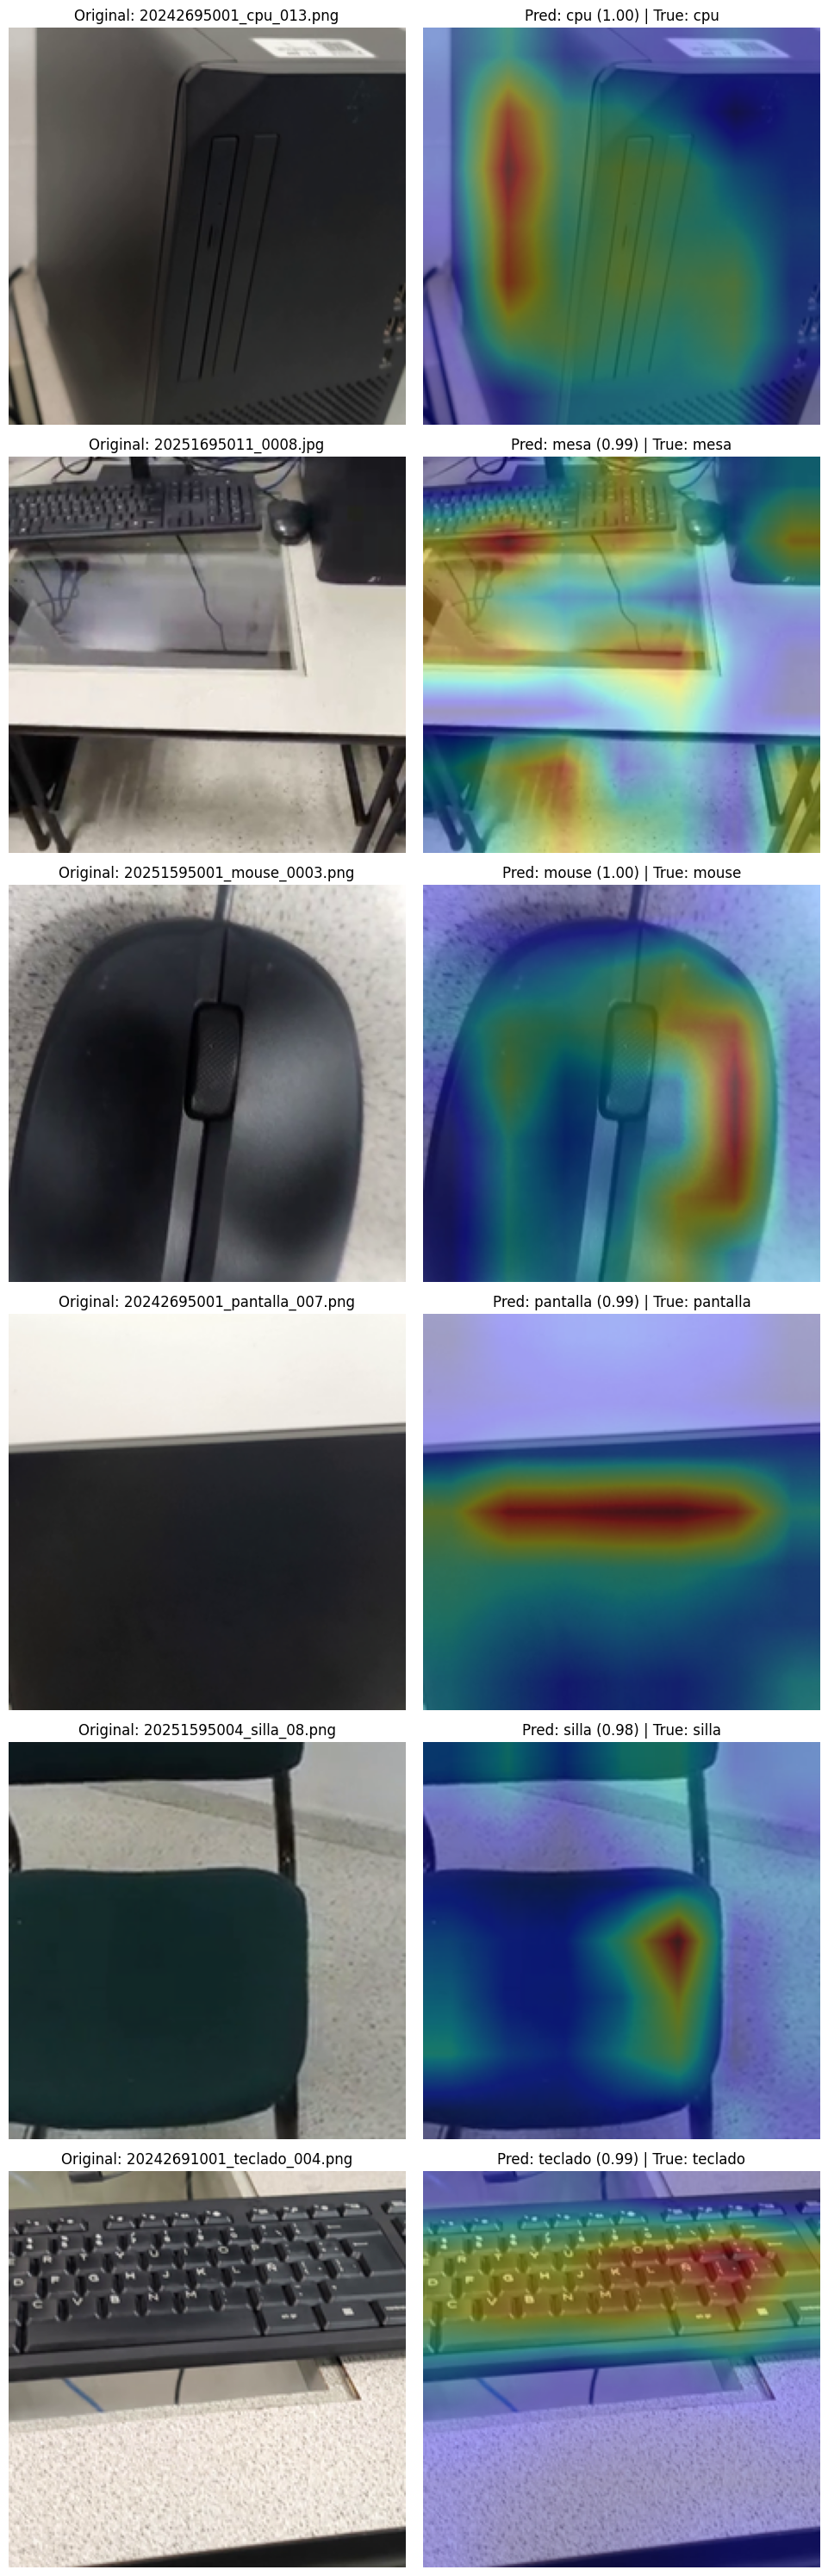


📊 Información de las imágenes visualizadas:


,path_basename,true_label,predicted_label,probability
0,20242695001_cpu_013.png,cpu,cpu,0.996268
1,20251695011_0008.jpg,mesa,mesa,0.994657
2,20251595001_mouse_0003.png,mouse,mouse,0.995228
3,20242695001_pantalla_007.png,pantalla,pantalla,0.985160
4,20251595004_silla_08.png,silla,silla,0.977983
5,20242691001_teclado_004.png,teclado,teclado,0.993497



✅ Hooks de Grad-CAM eliminados.

🎉 Generación de visualizaciones Grad-CAM completada.


In [ ]:
# CELDA 015
'''
Grad-CAM (6 imágenes de test).
Visualiza 6 casos de test con Grad-CAM sobre la última capa conv del encoder (EfficientNet-B0).
'''

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os # Para basename
from torchvision.utils import make_grid # Utilidad para denormalizar y convertir a PIL/numpy

print("🚀 Iniciando generación de visualizaciones Grad-CAM...")

# Parámetros (deben existir de celdas anteriores: clf_model, test_loader, class_to_idx, device)
if 'clf_model' not in globals() or 'test_loader' not in globals() or 'class_to_idx' not in globals() or 'device' not in globals():
     raise RuntimeError("Variables necesarias (clf_model, test_loader, class_to_idx, device) no encontradas. Asegúrate de ejecutar las celdas anteriores.")

# Asegurarse de que el modelo está en eval mode
clf_model.eval()
print(f"\n✅ Modelo configurado en modo evaluación.")


# 1. Helper Grad-CAM
# Registra hooks para capturar activaciones y gradientes de la última capa convolucional del encoder.
# La última capa conv en EfficientNet-B0 features es features[-1]
target_layer = clf_model.encoder.features[-1]

activations = None
grads = None

def save_activations(module, input, output):
    global activations
    activations = output.detach()

# Reverted to use register_backward_hook
def save_grads(module, grad_input, grad_output):
    global grads
    # For register_backward_hook, grad_output is typically a tuple containing gradient w.r.t. output
    # Taking the first element which is usually the gradient w.r.t. output
    grads = grad_output[0].detach()


# Eliminar hooks previos si existen (útil si la celda se ejecuta varias veces)
# Check for both forward and backward hook handles and remove if present
if hasattr(target_layer, '_forward_hook_handle'):
    try:
        target_layer._forward_hook_handle.remove()
    except RuntimeError:
        pass # Handle case where hook was already removed
    del target_layer._forward_hook_handle
if hasattr(target_layer, '_backward_hook_handle'): # Handle name for regular backward hook
    try:
        target_layer._backward_hook_handle.remove()
    except RuntimeError:
        pass # Handle case where hook was already removed
    del target_layer._backward_hook_handle
# Also check for full backward hook handle in case it was previously registered
if hasattr(target_layer, '_full_backward_hook_handle'): # Handle name for full backward hook
    try:
        target_layer._full_backward_hook_handle.remove()
    except RuntimeError:
        pass
    del target_layer._full_backward_hook_handle


# Registrar hooks
# Register the forward hook
target_layer._forward_hook_handle = target_layer.register_forward_hook(save_activations)
# Register the regular backward hook
target_layer._backward_hook_handle = target_layer.register_backward_hook(save_grads)


print(f"\n✅ Hooks registrados en la capa: {type(target_layer).__name__}")


def gradcam_on_batch(imgs, target_indices):
    """
    Calcula Grad-CAM para un batch de imágenes y sus índices objetivo.
    imgs: batch de imágenes [B, 3, H, W]
    target_indices: tensor de índices de clase objetivo [B]
    """
    global activations, grads # Usar las variables globales

    # Limpiar hooks después de usarlos en cada batch si no se quieren acumular
    # Aunque para un batch único, no es estrictamente necesario limpiarlos aquí.
    # target_layer._forward_hook_handle.remove()
    # target_layer._backward_hook_handle.remove()
    # hooks are kept registered globally for simplicity in this notebook cell

    # Forward pass
    logits, _, _ = clf_model(imgs)
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(logits, dim=1) # Guardar predicciones también

    # Calcular gradientes de la clase objetivo con respect to the logits
    # Need to create a scalar loss for backward to work.
    # We want the gradient of the logit corresponding to the target class for each sample.
    # This can be achieved by creating a loss that is the sum of the target logits.
    clf_model.zero_grad()
    # Select the logits corresponding to the target indices for each item in the batch
    target_logits = logits[torch.arange(logits.size(0)), target_indices]
    loss = target_logits.sum() # Sum the target logits to create a scalar loss for backward

    # Use AMP autocast if available
    with torch.amp.autocast(device_type=imgs.device.type):
        loss.backward() # Calculate gradients

    # Asegurarse de que los gradientes y activaciones se capturaron
    if grads is None or activations is None:
         raise RuntimeError("Error al capturar gradientes o activaciones. Asegúrate de que los hooks están registrados y el forward/backward se ejecutaron.")

    # Promediar gradientes espacialmente por canal (Global Average Pooling de gradientes)
    # grads shape: [B, C, H, W]
    weights = torch.mean(grads, dim=[2, 3], keepdim=True) # weights shape: [B, C, 1, 1]

    # Multiplicar pesos por activaciones y sumar a través de canales
    # activations shape: [B, C, H', W'] donde H', W' son las dimensiones espaciales de la capa objetivo (7x7)
    cam = torch.sum(weights * activations, dim=1, keepdim=True) # cam shape: [B, 1, H', W']

    # Aplicar ReLU (solo activaciones positivas contribuyen a la CAM)
    cam = F.relu(cam) # cam shape: [B, 1, H', W']

    # Upsample CAM a las dimensiones de la imagen original (224x224)
    cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False) # cam shape: [B, 1, 224, 224]

    # Normalizar CAM a rango [0, 1]
    cam_min, cam_max = cam.min(dim=-1, keepdim=True)[0].min(dim=-2, keepdim=True)[0].min(dim=1, keepdim=True)[0], cam.max(dim=-1, keepdim=True)[0].max(dim=-2, keepdim=True)[0].max(dim=1, keepdim=True)[0]
    cam = (cam - cam_min) / (cam_max - cam_min + 1e-8) # Añadir epsilon para evitar división por cero
    cam = cam.squeeze(1) # cam shape: [B, 224, 224]

    return cam, probs, preds # Devolver CAMs, probabilidades y predicciones

print("✅ Función gradcam_on_batch definida.")


# 2. Selección de 6 imágenes (una por clase si es posible)
print("\n🔄 Seleccionando 6 imágenes de test para Grad-CAM...")

idx_to_class = {v: k for k, v in class_to_idx.items()}
selected_samples = {} # {class_idx: (image_tensor, label_tensor, path)}

# Recorrer el test_loader hasta encontrar una imagen por cada clase objetivo
with torch.no_grad():
    for inputs, labels, paths in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        for i in range(inputs.size(0)):
            img_tensor = inputs[i]
            label_tensor = labels[i]
            img_path = paths[i]
            class_idx = label_tensor.item()

            if class_idx not in selected_samples:
                selected_samples[class_idx] = (img_tensor, label_tensor, img_path)

        if len(selected_samples) == len(class_to_idx):
            break # Ya tenemos una muestra por cada clase

# Si no se encontraron 6 clases (ej. test set pequeño), tomar las primeras que se encontraron
if len(selected_samples) < len(class_to_idx):
    print(f"⚠️ Solo se encontraron {len(selected_samples)} clases únicas en el conjunto de test. Seleccionando las disponibles.")
    # Convertir a lista y tomar las que haya
    selected_samples_list = list(selected_samples.values())
else:
     # Convertir a lista y ordenar por índice de clase
     selected_samples_list = sorted(selected_samples.values(), key=lambda x: x[1].item())


if not selected_samples_list:
     print("❌ No se pudieron seleccionar imágenes para Grad-CAM.")
else:
    # Preparar batch para Grad-CAM
    gradcam_imgs = torch.stack([s[0] for s in selected_samples_list])
    gradcam_labels = torch.stack([s[1] for s in selected_samples_list]) # True labels
    gradcam_paths = [s[2] for s in selected_samples_list]

    print(f"✅ {len(selected_samples_list)} imágenes seleccionadas.")


# 3. Calcular Grad-CAM y visualizar
if selected_samples_list:
    print("\n📈 Calculando Grad-CAM y generando visualizaciones...")

    # targets para Grad-CAM: usar las etiquetas verdaderas o predichas?
    # Usaremos las predichas para ver qué llevó al modelo a esa decisión.
    # Primero hacemos un forward pass solo para obtener las predicciones de estas imágenes
    with torch.no_grad():
        logits_selected, _, _ = clf_model(gradcam_imgs.to(device))
        predicted_indices = torch.argmax(logits_selected, dim=1)


    # Calcular Grad-CAM usando los índices predichos como target
    # Mover imágenes a device antes de pasarlas a gradcam_on_batch
    cams, probs, preds_cam = gradcam_on_batch(gradcam_imgs.to(device), predicted_indices.to(device)) # Pass predicted indices as target

    # Mover cams y probs de vuelta a CPU para visualización
    cams = cams.cpu().numpy()
    probs = probs.cpu().detach().numpy() # Add .detach() before .numpy()
    preds_cam = preds_cam.cpu().detach().numpy() # Add .detach() before .numpy()


    # Función para denormalizar imagen (inversa de Normalize)
    # Assuming ImageNet stats were used for normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    def denorm_img(tensor_img):
        """ Denormaliza un tensor de imagen (batch o single) y clipea a [0,1]. """
        # Si es un solo tensor, añadir una dimensión de batch
        if tensor_img.ndim == 3:
             tensor_img = tensor_img.unsqueeze(0) # [1, C, H, W]

        # Mover mean y std al mismo dispositivo que tensor_img
        mean_device = mean.to(tensor_img.device)
        std_device = std.to(tensor_img.device)

        denormed = tensor_img * std_device + mean_device
        denormed = torch.clamp(denormed, 0, 1)
        return denormed.squeeze(0) # Si era single, quitar la dimensión de batch


    # Visualizar
    num_samples_to_plot = len(selected_samples_list)
    if num_samples_to_plot == 0:
         print("❌ No hay imágenes para visualizar.")
    else:
        # Ajustar layout en función del número de muestras (2 cols)
        n_cols = 2
        n_rows = num_samples_to_plot
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows))

        # Ensure axes is always 2D array for easy indexing
        if n_rows == 1:
             axes = axes.reshape(1, -1)


        gradcam_samples_info = [] # Para la tablita final

        for i in range(num_samples_to_plot):
            img_tensor = gradcam_imgs[i]
            true_label_idx = gradcam_labels[i].item()
            predicted_label_idx = preds_cam[i] # Usar la predicción de gradcam_on_batch
            prob = probs[i, predicted_label_idx]
            img_path = gradcam_paths[i]

            true_class_name = idx_to_class[true_label_idx]
            predicted_class_name = idx_to_class[predicted_label_idx]
            path_basename = os.path.basename(img_path)

            # Denormalizar imagen para mostrar
            img_display = denorm_img(img_tensor).permute(1, 2, 0).cpu().numpy() # [H, W, C]

            # CAM (ya es [H, W])
            cam_display = cams[i]

            # Plot imagen original
            ax1 = axes[i, 0]
            ax1.imshow(img_display)
            ax1.set_title(f"Original: {path_basename}")
            ax1.axis('off')

            # Plot overlay de CAM
            ax2 = axes[i, 1]
            ax2.imshow(img_display)
            # Mostrar CAM con transparencia
            im = ax2.imshow(cam_display, cmap='jet', alpha=0.35)
            ax2.set_title(f"Pred: {predicted_class_name} ({prob:.2f}) | True: {true_class_name}")
            ax2.axis('off')

            # Añadir info a la tabla
            gradcam_samples_info.append({
                'path_basename': path_basename,
                'true_label': true_class_name,
                'predicted_label': predicted_class_name,
                'probability': prob
            })

        plt.tight_layout()
        plt.show()

        print("\n📊 Información de las imágenes visualizadas:")
        gradcam_samples_df = pd.DataFrame(gradcam_samples_info)
        display(gradcam_samples_df)

        # Dejar objetos en memoria
        gradcam_samples = gradcam_samples_info # Lista de dicts
        gradcam_fig = fig # Objeto figura

else:
    print("⚠️ No se pudieron generar visualizaciones Grad-CAM.")


# Eliminar hooks después de la visualización (para no interferir con otras operaciones)
# Check for both forward and full backward hook handles and remove if present
if hasattr(target_layer, '_forward_hook_handle'):
    try:
        target_layer._forward_hook_handle.remove()
    except RuntimeError:
        pass
    del target_layer._forward_hook_handle
if hasattr(target_layer, '_full_backward_hook_handle'): # Handle name for full backward hook
    try:
        target_layer._full_backward_hook_handle.remove()
    except RuntimeError:
        pass
    del target_layer._full_backward_hook_handle
# Ensure regular backward hook is also removed if present
if hasattr(target_layer, '_backward_hook_handle'): # Handle name for regular backward hook
    try:
        target_layer._backward_hook_handle.remove()
    except RuntimeError:
        pass
    del target_layer._backward_hook_handle


print("\n✅ Hooks de Grad-CAM eliminados.")


print("\n🎉 Generación de visualizaciones Grad-CAM completada.")

# Variables disponibles: gradcam_samples, gradcam_fig, clf_model, test_loader, class_to_idx, device

In [ ]:
# CELDA 016
'''
Inferencia por lote en TEST + CSV.
Recorre el conjunto de test, obtiene las predicciones del modelo y guarda los resultados en un archivo CSV.
'''

import os
import torch
import torch.nn.functional as F
import pandas as pd
import time

print("🚀 Iniciando inferencia en el conjunto de TEST y generación de CSV...")

# Parámetros (deben existir de celdas anteriores: clf_model, test_loader, class_to_idx, device)
if 'clf_model' not in globals() or 'test_loader' not in globals() or 'class_to_idx' not in globals() or 'device' not in globals():
     raise RuntimeError("Variables necesarias (clf_model, test_loader, class_to_idx, device) no encontradas. Asegúrate de ejecutar las celdas anteriores.")

# Determinar ruta de salida robustamente
if 'outputs' in globals():
    csv_dir = os.path.join(outputs, "tablas")
    print(f"\n✅ Usando 'outputs' para la ruta de salida: {outputs}")
elif 'resultados' in globals():
    csv_dir = os.path.join(resultados, "tablas")
    print(f"\n✅ Usando 'resultados' para la ruta de salida: {resultados}")
else:
    csv_dir = os.path.join(".", "outputs", "tablas") # Default to current dir
    print(f"\n⚠️ Rutas 'outputs' y 'resultados' no encontradas. Usando ruta por defecto: {csv_dir}")


# Crear directorio de salida si no existe
os.makedirs(csv_dir, exist_ok=True)
CSV_PATH = os.path.join(csv_dir, "predicciones_test.csv")
print(f"✅ Directorio de salida para CSV asegurado: {csv_dir}")
print(f"✅ Ruta de guardado del CSV: {CSV_PATH}")


# Configurar modelo para inferencia
clf_model.eval()
print(f"\n✅ Modelo configurado en modo evaluación en device: {device.upper()}")
print(f"  Tamaño del conjunto de Test: {len(test_loader.dataset)}")

# Invertir class_to_idx para mapear índices a nombres de clase
idx_to_class = {v: k for k, v in class_to_idx.items()}


# Bucle de inferencia en test
print("\n🔄 Realizando inferencia en el conjunto de test...")
results_list = []
start_time = time.time()

with torch.no_grad(): # Deshabilitar cálculo de gradientes
    for i, (inputs, labels, paths) in enumerate(test_loader):
        inputs = inputs.to(device)
        y_true_batch = labels.cpu().numpy()

        # Forward pass
        with torch.amp.autocast(device_type=device): # Usar AMP para inferencia
            logits, _, _ = clf_model(inputs)

        # Obtener probabilidades y top K predicciones
        probs = F.softmax(logits, dim=1)
        top_probs, top_indices = torch.topk(probs, k=2, dim=1) # Top 1 y Top 2

        # Mover resultados a CPU y convertir a numpy/listas
        top_probs = top_probs.cpu().numpy()
        top_indices = top_indices.cpu().numpy()

        # Acumular resultados por cada muestra en el batch
        for j in range(inputs.size(0)):
            true_label = idx_to_class[int(y_true_batch[j])]
            pred_idx = int(top_indices[j, 0])
            pred_label = idx_to_class[pred_idx]
            pred_score = float(top_probs[j, 0])
            top2_idx = int(top_indices[j, 1])
            top2_label = idx_to_class[top2_idx]
            top2_score = float(top_probs[j, 1])

            results_list.append({
                "filepath": paths[j],
                "true_label": true_label, # Incluir etiqueta verdadera
                "pred_label": pred_label,
                "pred_idx": pred_idx,
                "pred_score": pred_score,
                "top2_label": top2_label,
                "top2_idx": top2_idx,
                "top2_score": top2_score,
            })

end_time = time.time()
inference_duration = end_time - start_time
print(f"✅ Inferencia completa en {inference_duration:.2f}s.")


# Crear DataFrame y guardar en CSV
print("\n📊 Creando DataFrame y guardando CSV...")
pred_df = pd.DataFrame(results_list)

# Definir orden de columnas deseado
column_order = ["filepath", "true_label", "pred_label", "pred_idx", "pred_score", "top2_label", "top2_idx", "top2_score"]
pred_df = pred_df[column_order] # Reordenar columnas


try:
    pred_df.to_csv(CSV_PATH, index=False)
    print(f"✅ Predicciones guardadas exitosamente en: {CSV_PATH}")
    print(f"  Número de filas guardadas: {len(pred_df)}")
except Exception as e:
    print(f"❌ Error al guardar el CSV: {e}")


print("\n📄 Vista previa del CSV generado:")
if not pred_df.empty:
    display(pred_df.head(8))
else:
    print("  DataFrame de predicciones vacío.")


print("\n🎉 Inferencia en TEST y generación de CSV completadas.")

# Dejar variables clave en memoria
# pred_csv_path, pred_df, clf_model, test_loader, class_to_idx, device

🚀 Iniciando inferencia en el conjunto de TEST y generación de CSV...

✅ Usando 'outputs' para la ruta de salida: /content/drive/MyDrive/taller8/outputs
✅ Directorio de salida para CSV asegurado: /content/drive/MyDrive/taller8/outputs/tablas
✅ Ruta de guardado del CSV: /content/drive/MyDrive/taller8/outputs/tablas/predicciones_test.csv

✅ Modelo configurado en modo evaluación en device: CUDA
  Tamaño del conjunto de Test: 91

🔄 Realizando inferencia en el conjunto de test...
✅ Inferencia completa en 3.71s.

📊 Creando DataFrame y guardando CSV...
✅ Predicciones guardadas exitosamente en: /content/drive/MyDrive/taller8/outputs/tablas/predicciones_test.csv
  Número de filas guardadas: 91

📄 Vista previa del CSV generado:


,filepath,true_label,pred_label,pred_idx,pred_score,top2_label,top2_idx,top2_score
0,/content/drive/MyDrive/taller8/datos/silla/202...,silla,silla,4,0.977539,mouse,2,0.012199
1,/content/drive/MyDrive/taller8/datos/silla/202...,silla,silla,4,0.947754,mouse,2,0.035492
2,/content/drive/MyDrive/taller8/datos/teclado/2...,teclado,teclado,5,0.993652,mesa,1,0.005077
3,/content/drive/MyDrive/taller8/datos/cpu/20242...,cpu,cpu,0,0.996094,mouse,2,0.002665
4,/content/drive/MyDrive/taller8/datos/mesa/2025...,mesa,mesa,1,0.994629,teclado,5,0.002207
5,/content/drive/MyDrive/taller8/datos/cpu/20242...,cpu,cpu,0,0.995605,teclado,5,0.002247
6,/content/drive/MyDrive/taller8/datos/pantalla/...,pantalla,pantalla,3,0.984863,mouse,2,0.012314
7,/content/drive/MyDrive/taller8/datos/silla/202...,silla,silla,4,0.998047,pantalla,3,0.001299



🎉 Inferencia en TEST y generación de CSV completadas.


In [ ]:
# CELDA 017
'''
Verificación de artefactos guardados y resumen final.
Comprueba la existencia y información básica de los archivos de salida clave
(encoder_ae.pth, model_best.pth, predicciones_test.csv) y muestra un checklist final.
'''

import os
import time
import hashlib
import pandas as pd

print("🚀 Verificando artefactos guardados y preparando resumen final...")

# Determinar el directorio base de artefactos
base_dir = None
if 'outputs' in globals() and os.path.exists(outputs):
    base_dir = outputs
    print(f"\n✅ Usando 'outputs' como directorio base: {base_dir}")
elif 'resultados' in globals() and os.path.exists(resultados):
    base_dir = resultados
    print(f"\n✅ Usando 'resultados' como directorio base: {base_dir}")
else:
    # Fallback a un directorio por defecto si las variables esperadas no existen o no son rutas válidas
    base_dir = os.path.join(".", "outputs") # Asumir una estructura local si no hay Drive montado/variables
    print(f"\n⚠️ Directorios 'outputs' ni 'resultados' encontrados/válidos. Usando ruta por defecto: {base_dir}")


# Definir rutas esperadas de los artefactos
pesos_dir_expected = os.path.join(base_dir, "pesos")
tablas_dir_expected = os.path.join(base_dir, "tablas")

encoder_ae_path_expected = os.path.join(pesos_dir_expected, "encoder_ae.pth")
model_best_path_expected = os.path.join(pesos_dir_expected, "model_best.pth")
pred_csv_path_expected = os.path.join(tablas_dir_expected, "predicciones_test.csv")

# Usar rutas en memoria si existen y parecen correctas, sino usar las esperadas
encoder_ae_path = globals().get('encoder_path', encoder_ae_path_expected)
model_best_path = globals().get('model_best_path', model_best_path_expected)
pred_csv_path = globals().get('pred_csv_path', pred_csv_path_expected)


print("\n--- Información de Artefactos ---")

def file_info(path):
    """ Obtiene información básica de un archivo: existencia, tamaño, fecha mod, hash MD5. """
    exists = os.path.exists(path)
    info = {"exists": exists, "size_mb": "N/A", "mtime_iso": "N/A", "md5_hash": "N/A", "path": path}

    if exists:
        try:
            size_bytes = os.path.getsize(path)
            info["size_mb"] = f"{size_bytes / (1024*1024):.3f}"

            mtime_ts = os.path.getmtime(path)
            info["mtime_iso"] = time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(mtime_ts))

            # Calcular MD5 hash del archivo (en chunks para archivos grandes)
            hash_md5 = hashlib.md5()
            try:
                with open(path, "rb") as f:
                    for chunk in iter(lambda: f.read(4096), b""):
                        hash_md5.update(chunk)
                info["md5_hash"] = hash_md5.hexdigest()
            except Exception as e:
                info["md5_hash"] = f"Error hashing: {e}"

        except Exception as e:
            print(f"⚠️ Error obteniendo info de {path}: {e}")

    return info

# Lista de artefactos a verificar
artefacts_to_check = [
    {"name": "Encoder AE Weights", "path": encoder_ae_path},
    {"name": "Best Classifier Model", "path": model_best_path},
    {"name": "Test Predictions CSV", "path": pred_csv_path},
]

# Recopilar y mostrar información de cada artefacto
artefact_results = []
for art in artefacts_to_check:
    info = file_info(art["path"])
    artefact_results.append(info)
    status_icon = "✅" if info["exists"] else "⚠️"
    hash_display = info["md5_hash"][:8] if info["md5_hash"] != "N/A" else "N/A"
    print(f"{status_icon} {art['name']}: Existe={info['exists']}, Tamaño={info['size_mb']} MB, Modificado={info['mtime_iso']}, MD5={hash_display}, Ruta={info['path']}")


# Mostrar vista previa del CSV si existe
print("\n--- Vista previa del CSV de Predicciones ---")
csv_info = next((item for item in artefact_results if "CSV" in item["path"]), None) # Find the CSV info
if csv_info and csv_info["exists"]:
    try:
        csv_preview_df = pd.read_csv(csv_info["path"], nrows=5)
        display(csv_preview_df)
        total_csv_rows = len(pd.read_csv(csv_info["path"])) # Get total rows
        print(f"\nℹ️ Total de filas en el CSV: {total_csv_rows}")
    except Exception as e:
        print(f"❌ Error al leer o mostrar vista previa del CSV: {e}")
        total_csv_rows = "N/A"
else:
    print("⚠️ Archivo CSV de predicciones no encontrado.")
    total_csv_rows = 0


# --- Checklist Final ---
print("\n--- Checklist Final ---")

# Confirmar archivos de pesos
encoder_exists = any(item['exists'] for item in artefact_results if "encoder_ae.pth" in item['path'])
model_exists = any(item['exists'] for item in artefact_results if "model_best.pth" in item['path'])
csv_exists = any(item['exists'] for item in artefact_results if "predicciones_test.csv" in item['path'])


print(f"{'✅' if encoder_exists else '⚠️'} Pesos del Encoder AE ({os.path.basename(encoder_ae_path)}) guardados correctamente.")
print(f"{'✅' if model_exists else '⚠️'} Checkpoint del Mejor Clasificador ({os.path.basename(model_best_path)}) guardado correctamente.")
print(f"{'✅' if csv_exists else '⚠️'} CSV de Predicciones de Test ({os.path.basename(pred_csv_path)}) generado correctamente.")

# Información de mapeo de clases
if 'class_to_idx' in globals():
     print(f"\nℹ️ Mapeo de clases (class_to_idx): {class_to_idx}")
else:
     print("\n⚠️ Mapeo de clases (class_to_idx) no encontrado en memoria.")


# Resumen de métricas de TEST si existen
if 'test_metrics' in globals():
     metrics = test_metrics
     print(f"\n📊 Resumen de Métricas en TEST:")
     print(f"  Accuracy: {metrics['acc']:.4f}")
     print(f"  Precision (Macro): {metrics['prec_macro']:.4f}")
     print(f"  Recall (Macro): {metrics['rec_macro']:.4f}")
     print(f"  F1-Score (Macro): {metrics['f1_macro']:.4f}")
else:
     print("\n⚠️ Métricas de TEST (test_metrics) no encontradas en memoria.")


print("\n🎉 Verificación de artefactos y resumen final completados.")

# Dejar variables clave en memoria
artifacts = {
    "encoder_ae_path": encoder_ae_path,
    "model_best_path": model_best_path,
    "pred_csv_path": pred_csv_path,
    "base_dir": base_dir,
    "total_csv_rows": total_csv_rows # Puede ser 0 o N/A si no se generó/leyó
}

# Variables disponibles: artifacts

🚀 Verificando artefactos guardados y preparando resumen final...

✅ Usando 'outputs' como directorio base: /content/drive/MyDrive/taller8/outputs

--- Información de Artefactos ---
✅ Encoder AE Weights: Existe=True, Tamaño=15.573 MB, Modificado=2025-10-22 03:59:27, MD5=89829e30, Ruta=/content/drive/MyDrive/taller8/outputs/pesos/encoder_ae.pth
✅ Best Classifier Model: Existe=True, Tamaño=46.415 MB, Modificado=2025-10-22 04:08:28, MD5=c48b52aa, Ruta=/content/drive/MyDrive/taller8/outputs/pesos/model_best.pth
✅ Test Predictions CSV: Existe=True, Tamaño=0.011 MB, Modificado=2025-10-22 04:29:52, MD5=ef7a49cc, Ruta=/content/drive/MyDrive/taller8/outputs/tablas/predicciones_test.csv

--- Vista previa del CSV de Predicciones ---
⚠️ Archivo CSV de predicciones no encontrado.

--- Checklist Final ---
✅ Pesos del Encoder AE (encoder_ae.pth) guardados correctamente.
✅ Checkpoint del Mejor Clasificador (model_best.pth) guardado correctamente.
✅ CSV de Predicciones de Test (predicciones_test.csv) ge